<a href="https://colab.research.google.com/github/suryasenthilr/image_caption_VGG_LSTM/blob/main/credit_risk_model_NB_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align='center' style='color:blue'>Random Process:Credit Risk Classification with a Self-Implemented Gaussian Naive Bayes Algorithm</h1>

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

### Load Data

In [2]:
df_customers = pd.read_csv("customers.csv")
df_loans = pd.read_csv("loans.csv")
df_bureau = pd.read_csv("bureau_data.csv")

In [3]:
df_customers.shape, df_loans.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [4]:
df_customers.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001


In [5]:
df_loans.head(3)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [6]:
df_bureau.head(3)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58


In [7]:
df = pd.merge(df_customers, df_loans, on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False


In [8]:
df = pd.merge(df, df_bureau, on='cust_id')
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [10]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

,count
default,
0,45703
1,4297


### Train Test split

In [11]:
X = df.drop("default", axis="columns")
y = df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

df_train.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0


<h3 align="center" style="color:blue">Data Cleaning</h3>

### Handle Missing & Duplicate Values

In [12]:
df_train.shape

(37500, 33)

In [13]:
df_train.isna().sum()

,0
cust_id,0
age,0
gender,0
marital_status,0
employment_status,0
income,0
number_of_dependants,0
residence_type,47
years_at_current_address,0
city,0


In [14]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [15]:
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [16]:
df_train.residence_type.fillna(mode_residence, inplace=True)
df_test.residence_type.fillna(mode_residence, inplace=True)

df_train.residence_type.unique(), df_test.residence_type.unique()

/tmp/ipykernel_775/2805913581.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train.residence_type.fillna(mode_residence, inplace=True)
/tmp/ipykernel_775/2805913581.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

(array(['Owned', 'Mortgage', 'Rented'], dtype=object),
 array(['Owned', 'Mortgage', 'Rented'], dtype=object))

In [17]:
df_train.duplicated().sum()

np.int64(0)

In [18]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,...,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00
mean,39.54,2633326.16,1.94,16.00,418866.25,4699691.57,3996067.73,80290.68,719292.19,3196854.19,...,1333819.51,986298.87,2.50,1.00,76.11,4.84,26.67,5.01,43.42,0.09
std,9.86,2623780.52,1.54,8.92,169035.02,6257832.98,5371862.29,113128.14,966935.21,4297489.83,...,1213674.44,1043145.01,1.12,0.81,43.77,5.84,32.78,2.03,29.39,0.28
min,18.00,0.00,0.00,1.00,110001.00,0.00,0.00,0.00,0.00,0.00,...,-1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,33.00,802000.00,0.00,8.00,302001.00,1142000.00,961000.00,19220.00,172980.00,768800.00,...,422197.50,287040.25,1.00,0.00,42.00,0.00,0.00,4.00,18.00,0.00
50%,39.00,1885000.00,2.00,16.00,400001.00,2644000.00,2230000.00,44600.00,401400.00,1784000.00,...,997427.50,665014.50,3.00,1.00,71.00,3.00,13.00,5.00,39.00,0.00
75%,46.00,3326250.00,3.00,24.00,560001.00,5178000.00,4619000.00,92420.00,831420.00,3695200.00,...,1784879.00,1234062.75,4.00,2.00,107.00,8.00,46.00,6.00,67.00,0.00
max,70.00,11999000.00,5.00,31.00,700001.00,52175000.00,47819000.00,5293543.52,8607420.00,38255200.00,...,5000000.00,7846643.00,4.00,2.00,223.00,24.00,171.00,9.00,99.00,1.00


In [19]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [20]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address',
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement',
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city',
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

### Box plot to visualize outliers

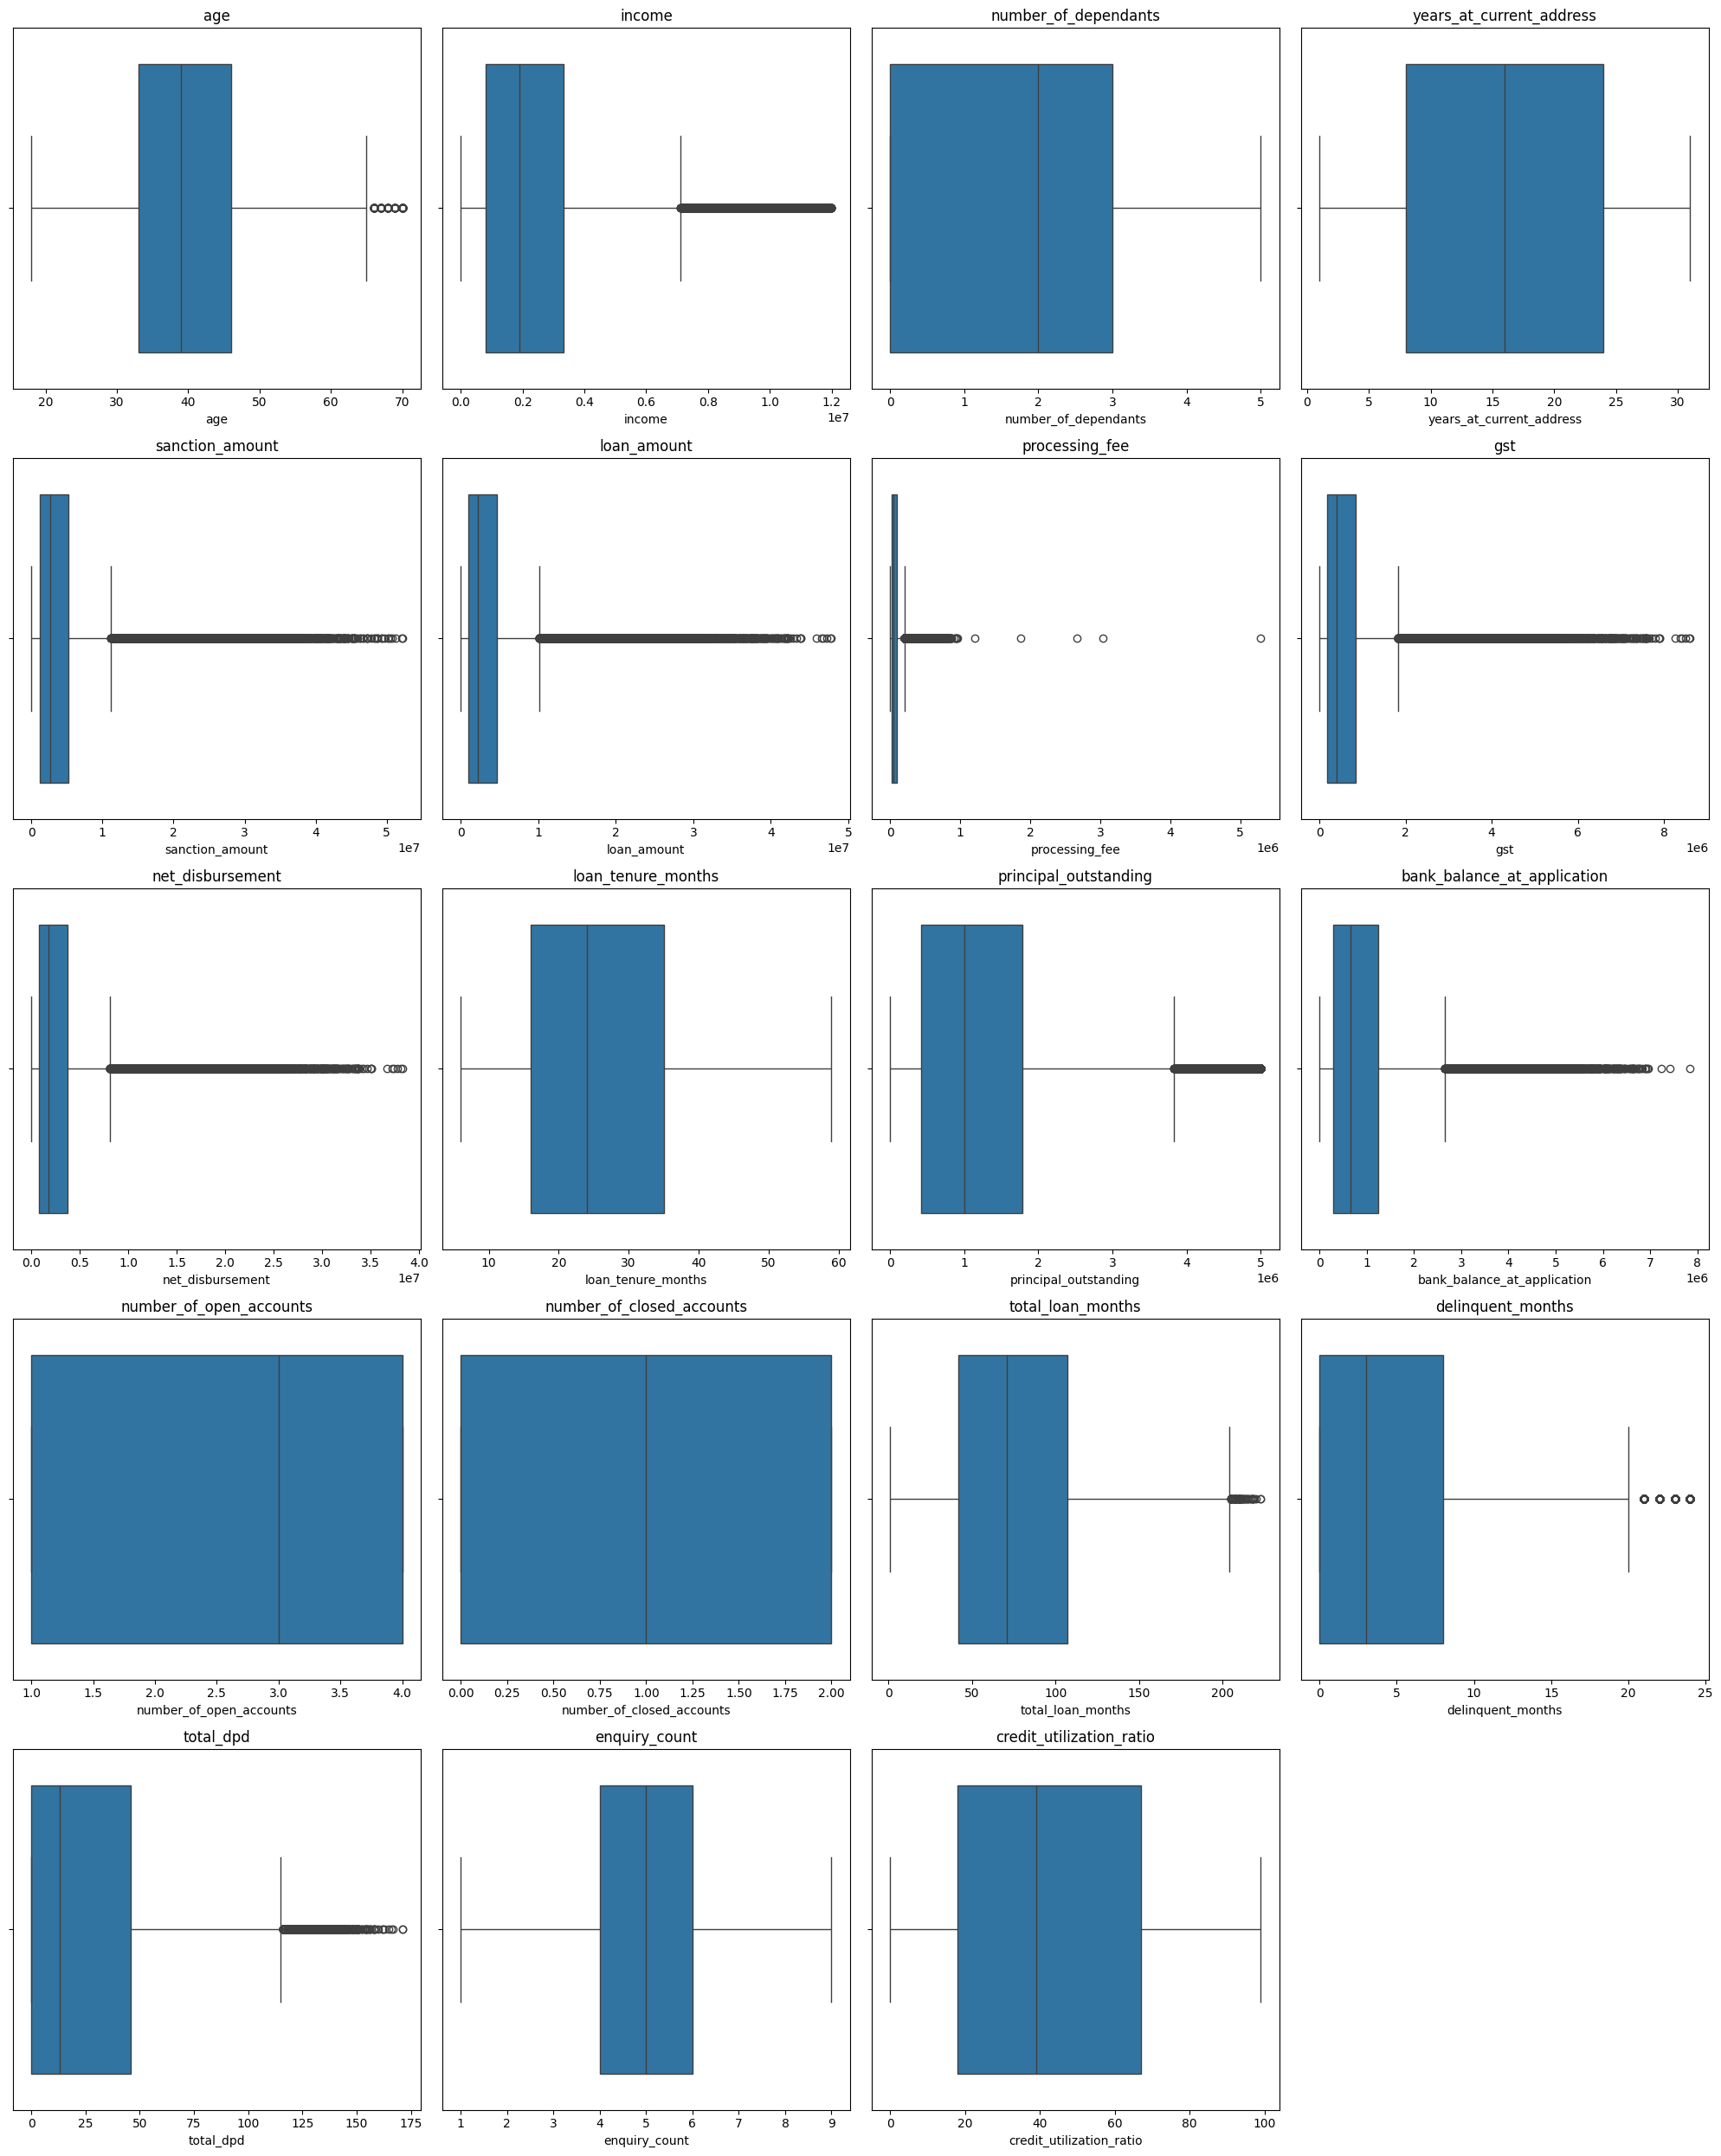

In [21]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

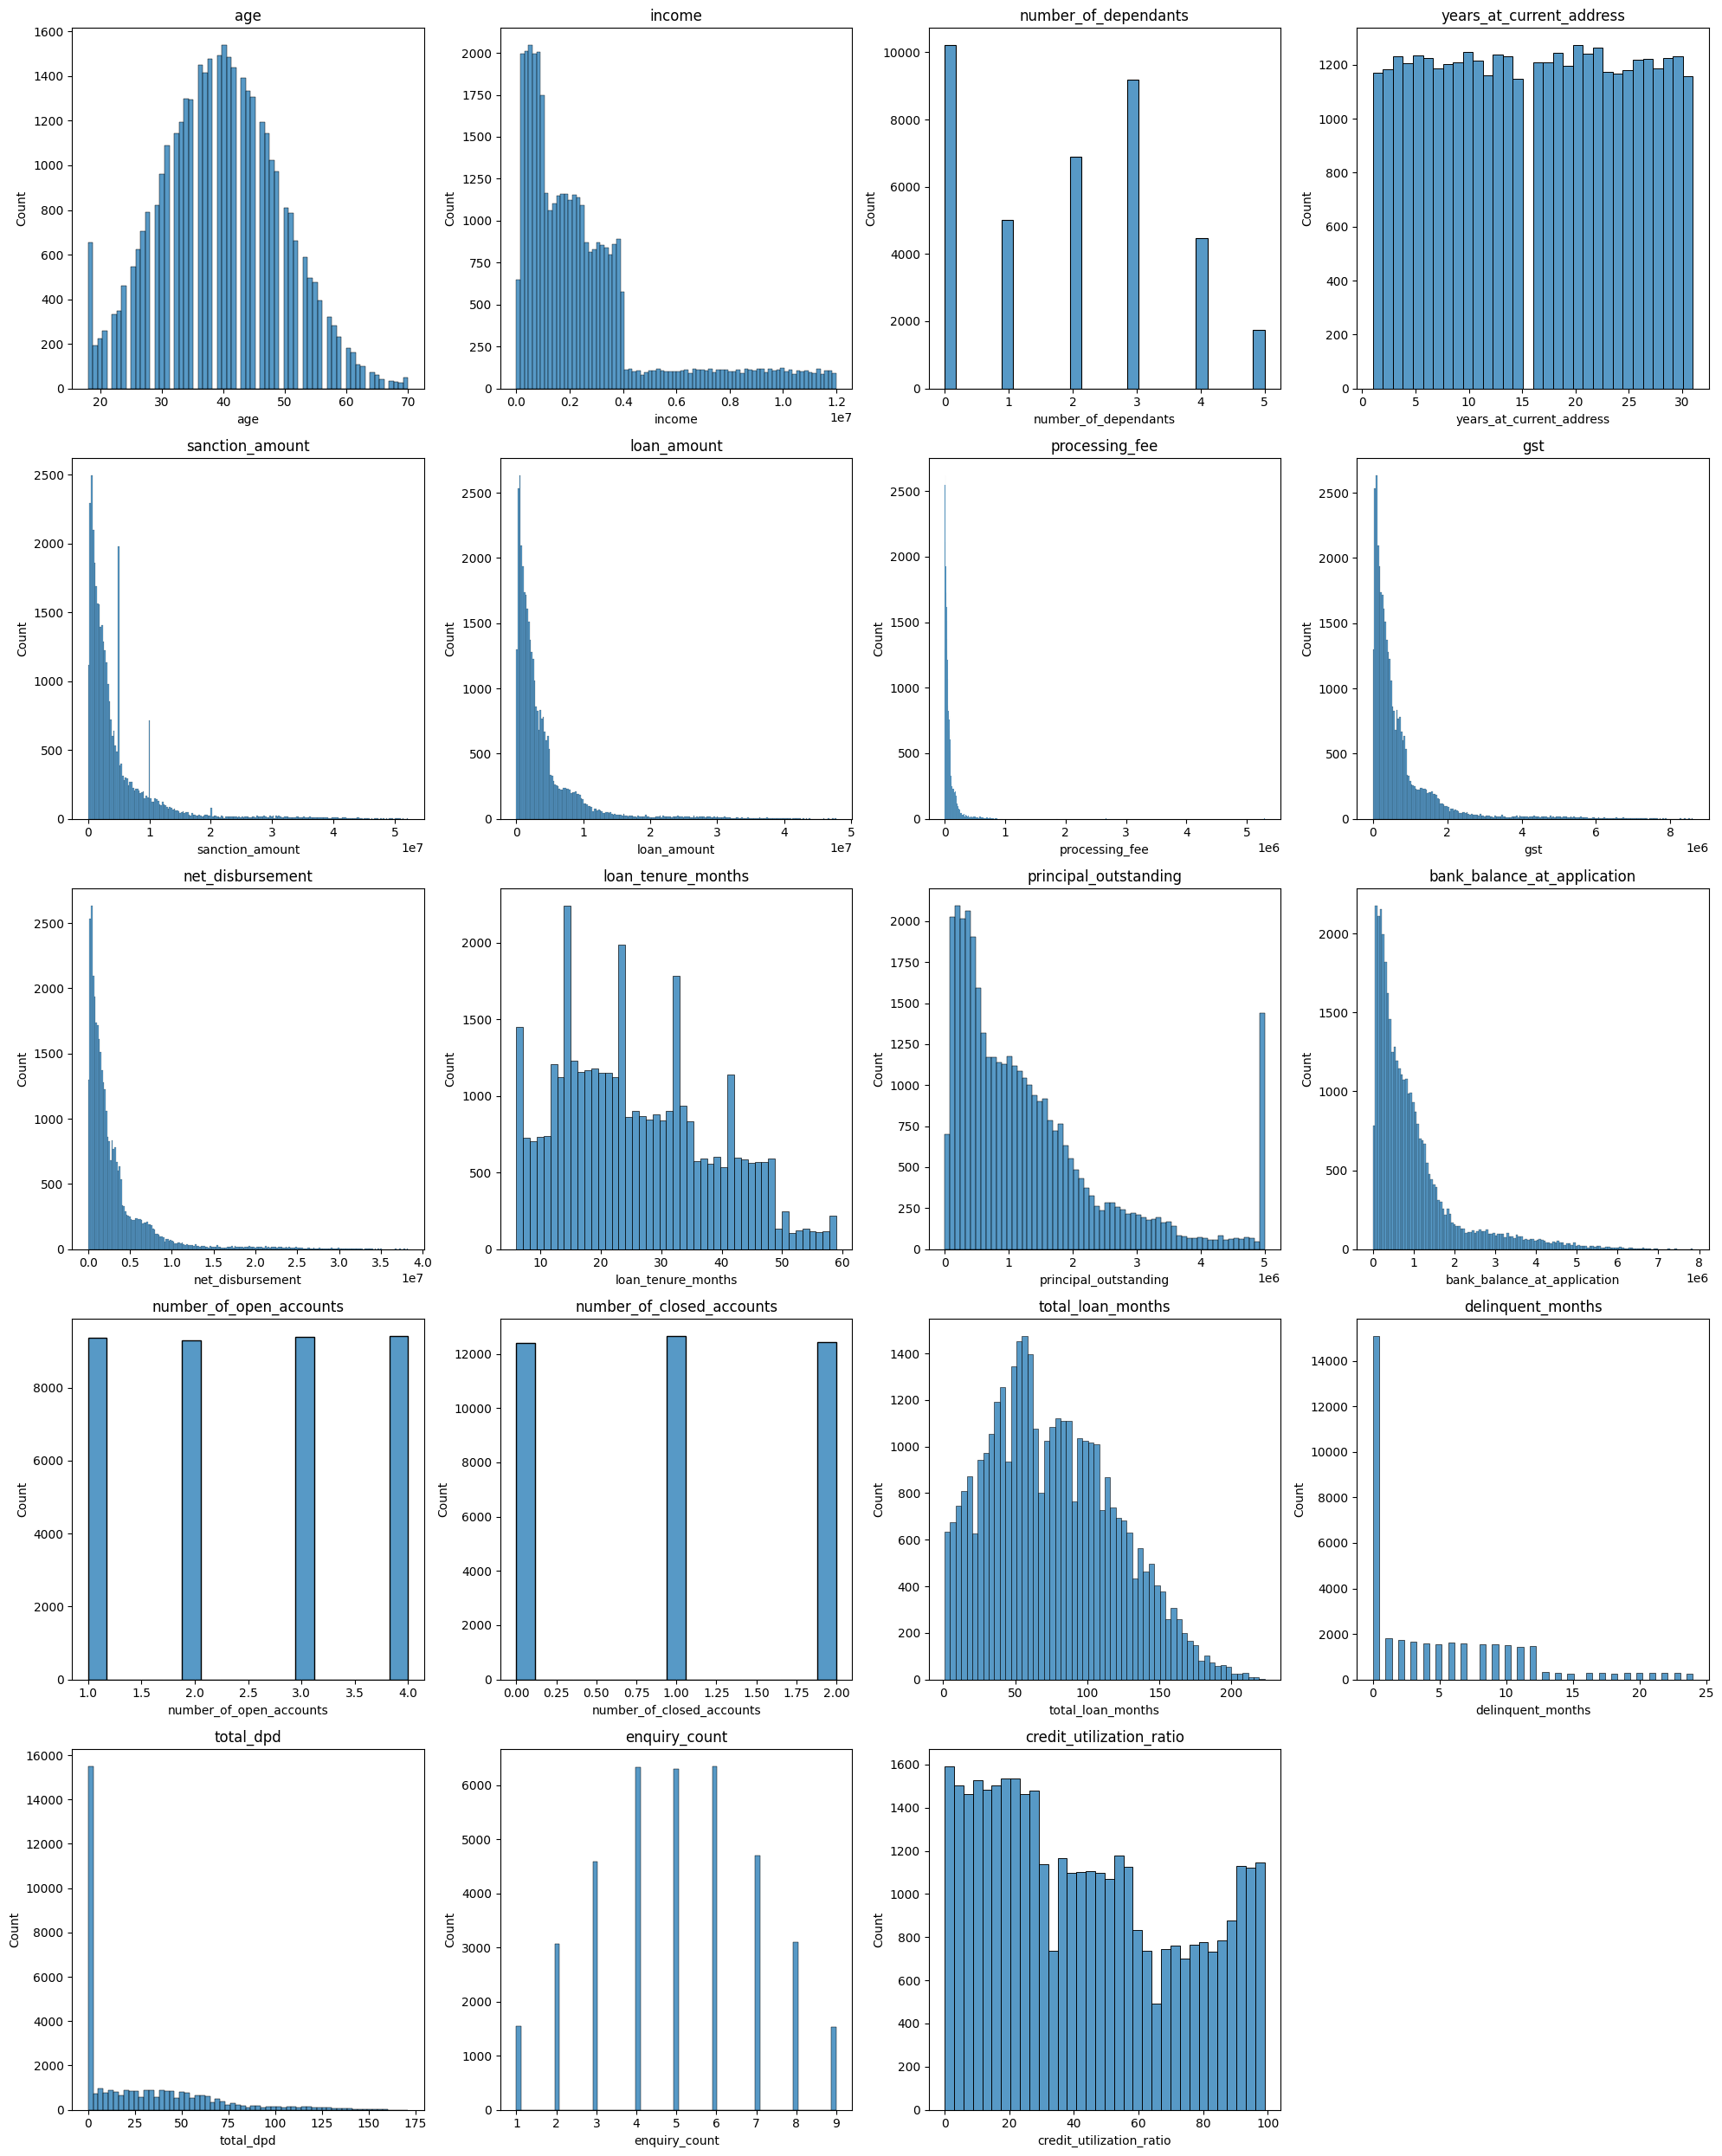

In [22]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.histplot(df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Outlier Removal: Processing Fee

In [23]:
df_train.processing_fee.describe()

,processing_fee
count,37500.00
mean,80290.68
std,113128.14
min,0.00
25%,19220.00
50%,44600.00
75%,92420.00
max,5293543.52


In [24]:
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][["loan_amount","processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


In [25]:
df_train_1 = df_train[df_train.processing_fee/df_train.loan_amount<0.03].copy()
df_train_1.shape

(37488, 33)

In [26]:
df_test.residence_type.isna().sum()

np.int64(0)

In [27]:
# Apply same step on test set
df_test = df_test[df_test.processing_fee/df_test.loan_amount<0.03].copy()
df_test.shape

(12497, 33)

In [28]:
# Use other business rules for data validation
# Rule 1: GST should not be more than 20%

df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.2].shape

(0, 33)

In [29]:
# Rule 2: Net disbursement should not be higher than loan_amount
df_train_1[df_train_1.net_disbursement>df_train_1.loan_amount].shape

(0, 33)

No rows found that breaks rule 1 and rule 2

### Analyze Categorical Columns

In [30]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [31]:
for col in columns_categorical:
    print(col, "-->", df_train_1[col].unique())

gender --> ['M' 'F']
marital_status --> ['Married' 'Single']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode --> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose --> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
default --> [0 1]


### Fix Errors in Loan Purpose Column

In [32]:
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal', 'Personal')
df_train_1['loan_purpose'].unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

In [33]:
df_test['loan_purpose'] = df_test['loan_purpose'].replace('Personaal', 'Personal')
df_test['loan_purpose'].unique()

array(['Home', 'Education', 'Auto', 'Personal'], dtype=object)

<h3 style="color:blue" align="center">Exploratory Data Analysis</h3>

In [34]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

### Age Column

In [35]:
df_train_1.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.00,39.77,9.88,18.00,33.00,40.00,46.00,70.00
1,3223.00,37.12,9.29,18.00,31.00,37.00,44.00,70.00


**Insights**

1. Average age in the default group is little less (37.12) than the average (39.7) of the group that did not default
1. Variability (standard deviation) is mostly similar in both the groups
1. Both the groups have similar min and max ages

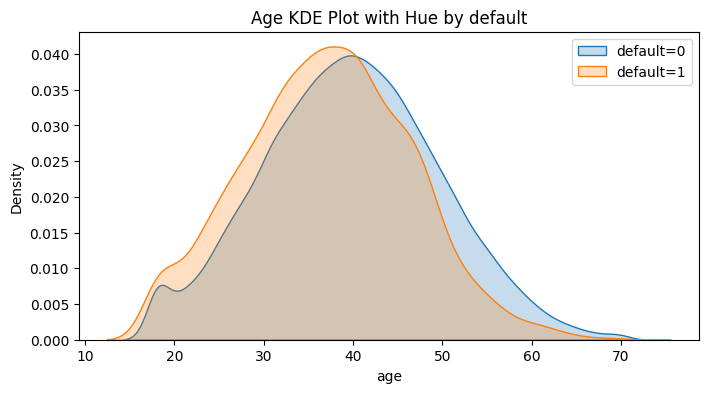

In [36]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['age'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['age'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Age KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Orange (defaulted) group is slightly shifted to left indicating that younger folks are more likely to default on their loans

### KDE for all the Columns

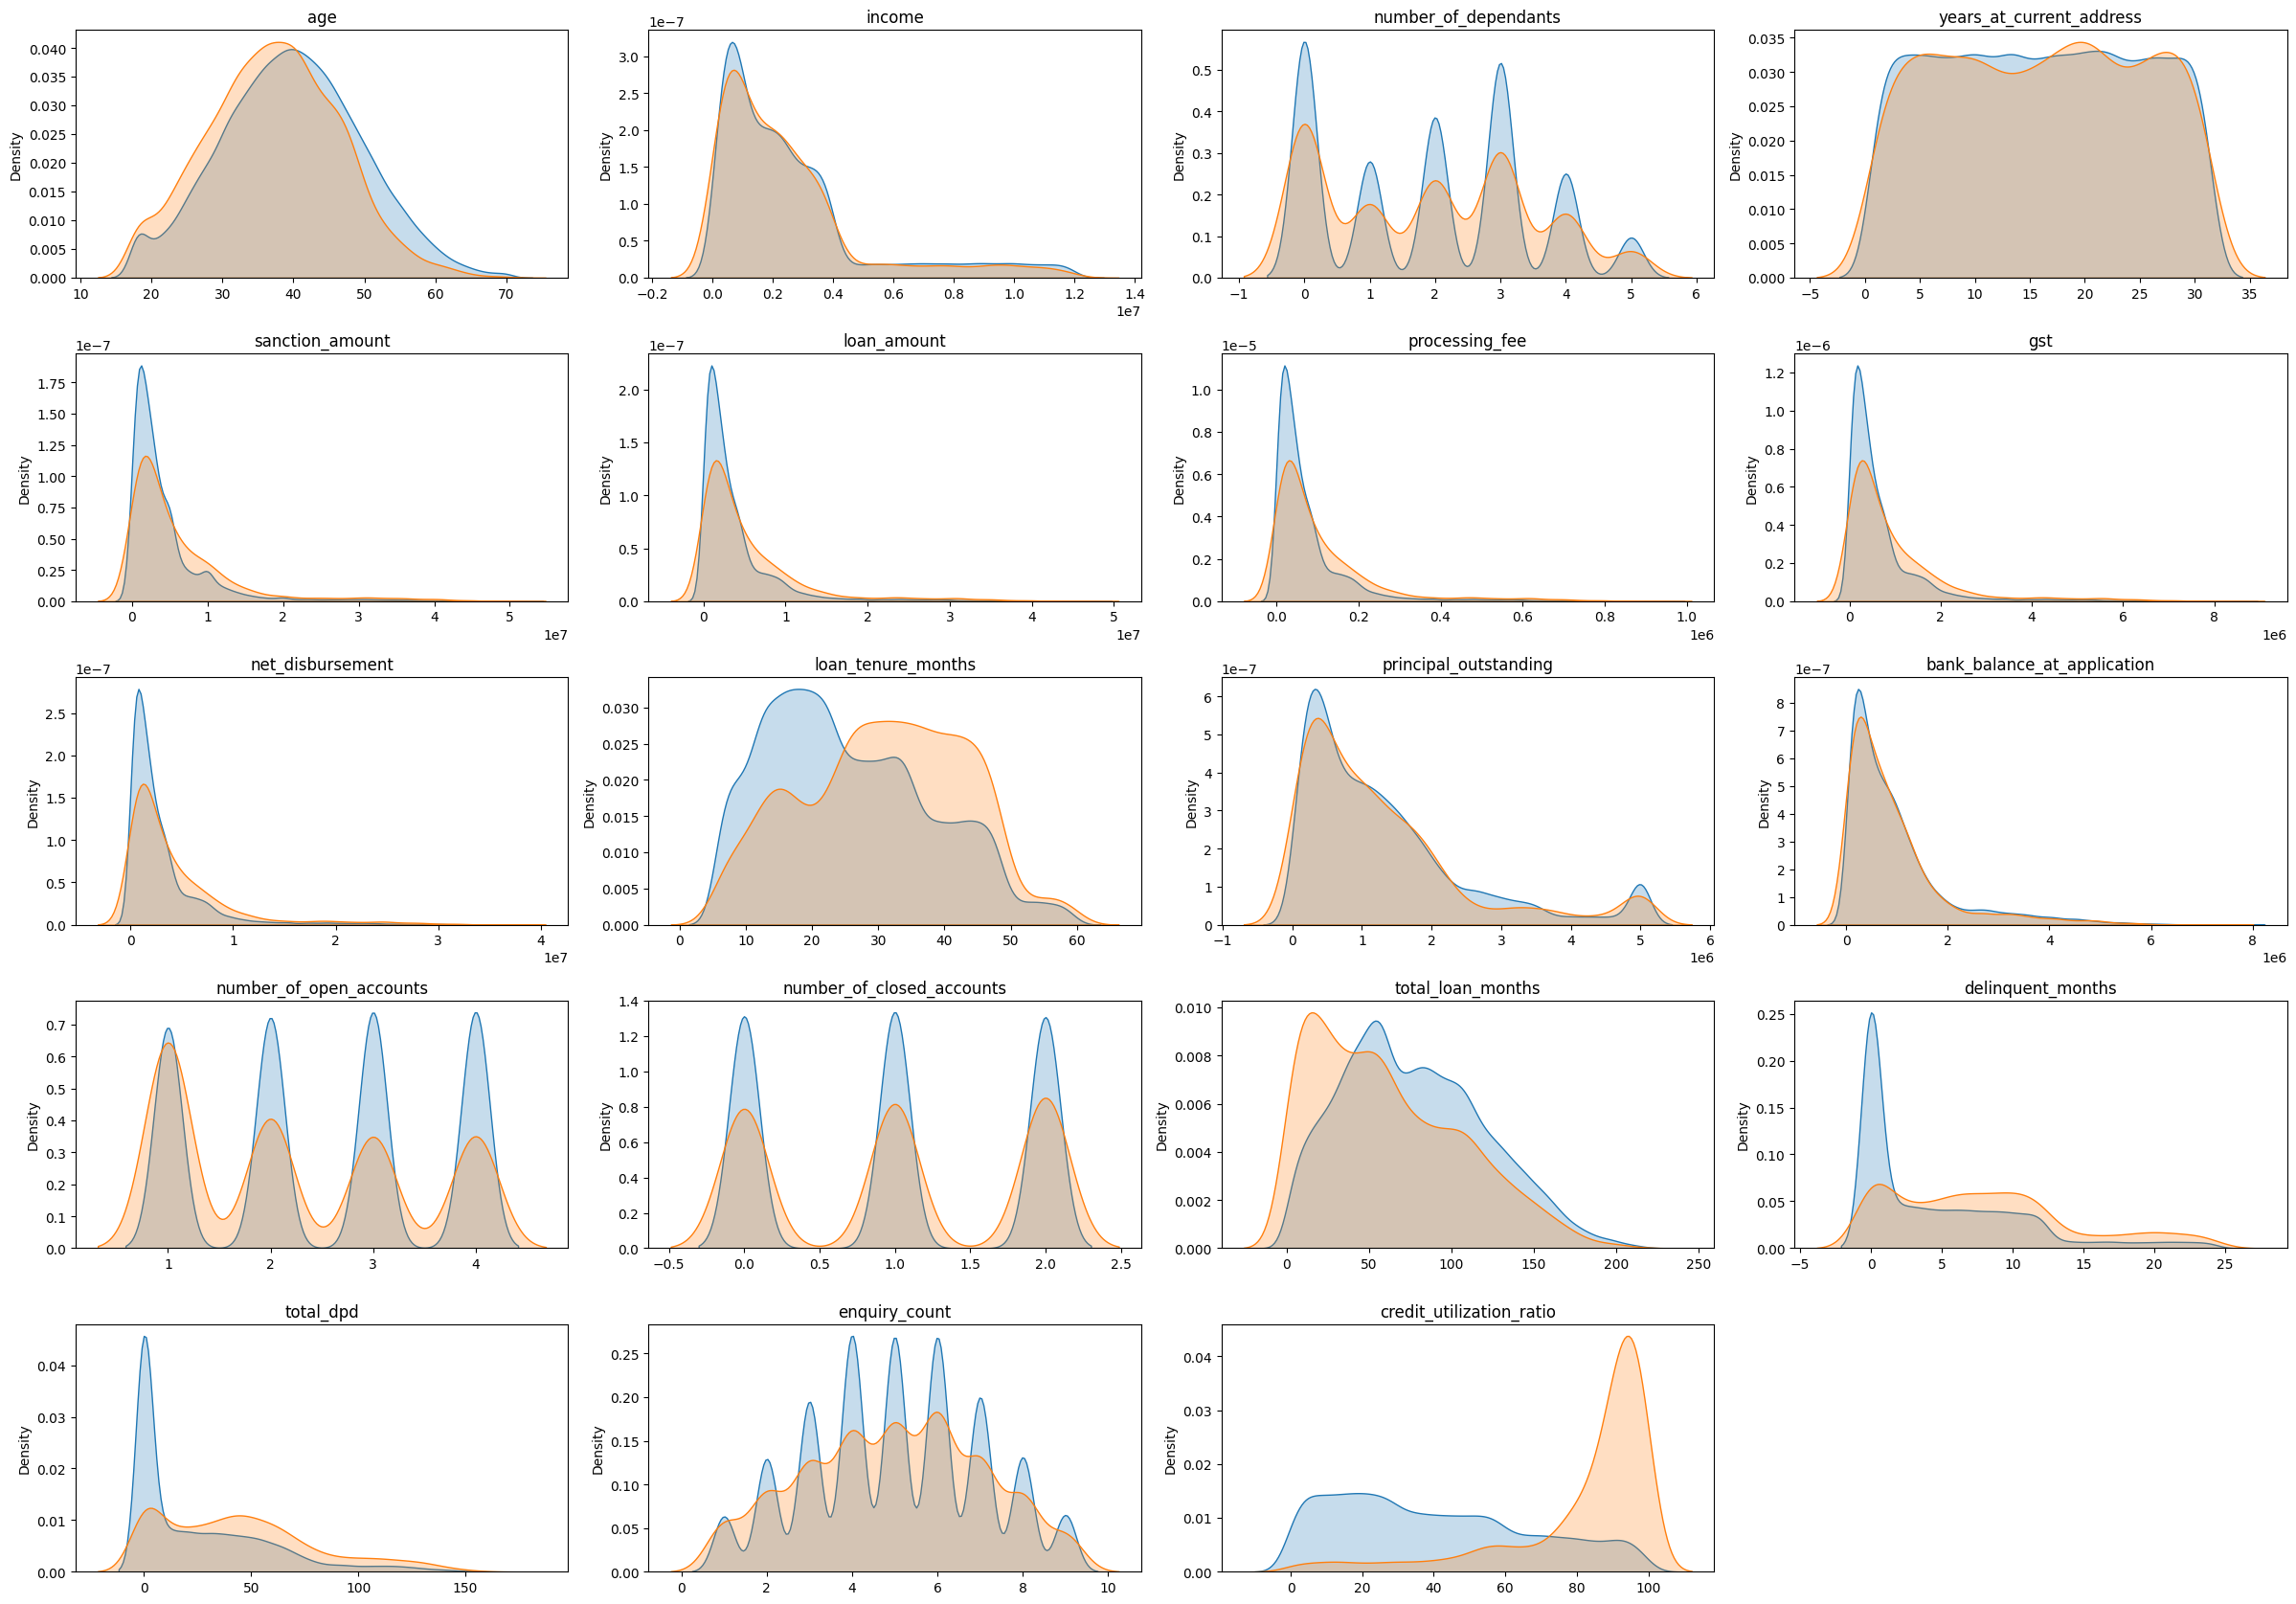

In [37]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train_1[col][df_train_1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train_1[col][df_train_1['default']==1], fill=True, label='default=1')
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()

**Insights**

1. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
1. In remaining columns the distributions do not give any obvious insights
1. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

<h3 style="color:blue" align="center">Feature Engineering, Feature Selection</h3>

#### Generate Loan to Income (LTI) Ratio

In [38]:
df_train_1[["loan_amount", "income"]].head(3)

,loan_amount,income
12746,23442000,11327000
32495,1149000,715000
43675,11296000,3195000


In [39]:
df_train_1['loan_to_income'] = round(df_train_1['loan_amount'] / df_train_1['income'],2)
df_train_1['loan_to_income'].describe()

,loan_to_income
count,37488.00
mean,1.56
std,0.97
min,0.30
25%,0.77
50%,1.16
75%,2.46
max,4.57


In [40]:
df_test['loan_to_income'] = round(df_test['loan_amount'] / df_test['income'],2)

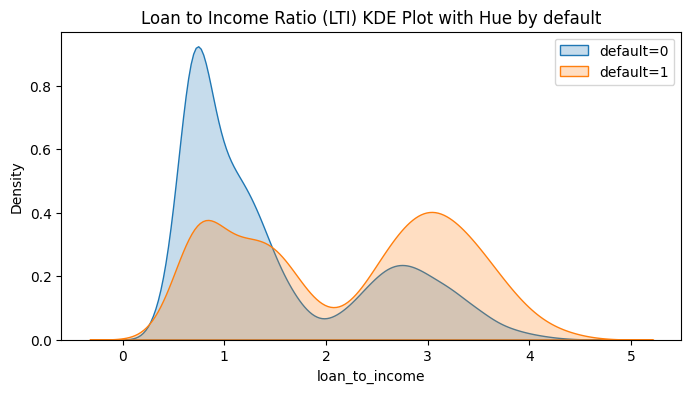

In [41]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Loan to Income Ratio (LTI) KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when LTI is higher indicating that higher LTI means high risk loan

#### Generate Delinquency Ratio

In [42]:
df_train_1['delinquency_ratio'] = (df_train_1['delinquent_months']*100 / df_train_1['total_loan_months']).round(1)
df_test['delinquency_ratio'] = (df_test['delinquent_months']*100 / df_test['total_loan_months']).round(1)

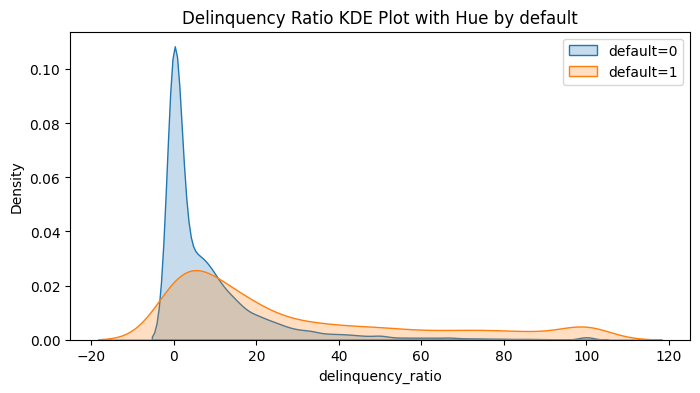

In [43]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['delinquency_ratio'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['delinquency_ratio'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**
1. Blue graph has majority of its values on lower side of LTI
2. Orange graph has many values when delinquency ratio is higher indicating some correlation on default

#### Generate Avg DPD Per Delinquency

In [44]:
df_train_1['avg_dpd_per_delinquency'] = np.where(
    df_train_1['delinquent_months'] != 0,
    (df_train_1['total_dpd'] / df_train_1['delinquent_months']).round(1),
    0
)

df_test['avg_dpd_per_delinquency'] = np.where(
    df_test['delinquent_months'] != 0,
    (df_test['total_dpd'] / df_test['delinquent_months']).round(1),
    0
)

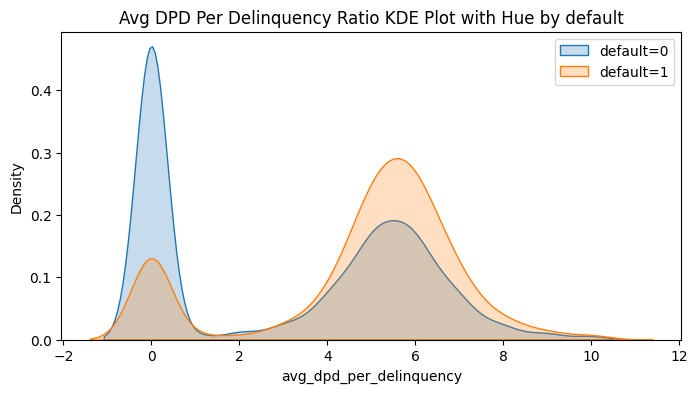

In [45]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['avg_dpd_per_delinquency'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['avg_dpd_per_delinquency'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Avg DPD Per Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Graph clearly shows more occurances of default cases when avg_dpd_per_delinquency is high. This means this column is a strong predictor

### Remove columns that are just unique ids and don't have influence on target

In [46]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [47]:
df_train_2 = df_train_1.drop(['cust_id', 'loan_id'],axis="columns")
df_test = df_test.drop(['cust_id', 'loan_id'],axis="columns")

### Remove columns that business contact person asked us to remove

In [48]:
df_train_3 = df_train_2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income',
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income',
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [49]:
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

### VIF to measure multicolinearity

In [50]:
X_train = df_train_3.drop('default', axis='columns')
y_train = df_train_3['default']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = X_train.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.40,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.62,0.68,0.51,0.13,0.57
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


#### Same transformation on test set

In [51]:
X_test = df_test.drop('default', axis='columns')
y_test = df_test['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00
mean,0.42,0.38,0.50,0.53,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.11,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.25,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.51,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.44
75%,0.54,0.60,0.77,0.76,0.10,0.09,0.09,0.09,0.55,0.36,0.16,0.67,1.00,0.62,0.68,0.50,0.13,0.58
max,1.00,1.00,1.00,1.00,0.98,0.96,0.96,0.96,1.00,1.00,0.94,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [53]:
X_train.head(2)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
12746,0.79,M,Married,Self-Employed,0.60,Owned,0.97,Hyderabad,Telangana,0.66,...,0.42,1.00,0.61,1.00,1.00,0.38,0.36,0.41,0.13,0.59
32495,0.50,F,Single,Salaried,0.00,Owned,0.87,Mumbai,Maharashtra,0.49,...,0.83,0.09,0.03,0.67,0.50,0.50,0.05,0.31,0.06,0.62


In [54]:
calculate_vif(X_train[cols_to_scale])

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.70
1,number_of_dependants,2.73
2,years_at_current_address,3.42
3,zipcode,3.80
4,sanction_amount,101.09
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.18
9,principal_outstanding,16.33


In [55]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [56]:
vif_df = calculate_vif(X_train_1[numeric_columns])
vif_df

,Column,VIF
0,age,5.43
1,number_of_dependants,2.73
2,years_at_current_address,3.40
3,zipcode,3.78
4,loan_tenure_months,6.02
5,bank_balance_at_application,1.80
6,number_of_open_accounts,4.35
7,number_of_closed_accounts,2.37
8,enquiry_count,6.38
9,credit_utilization_ratio,2.92


In [57]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'], dtype=object)

In [58]:
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [59]:
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

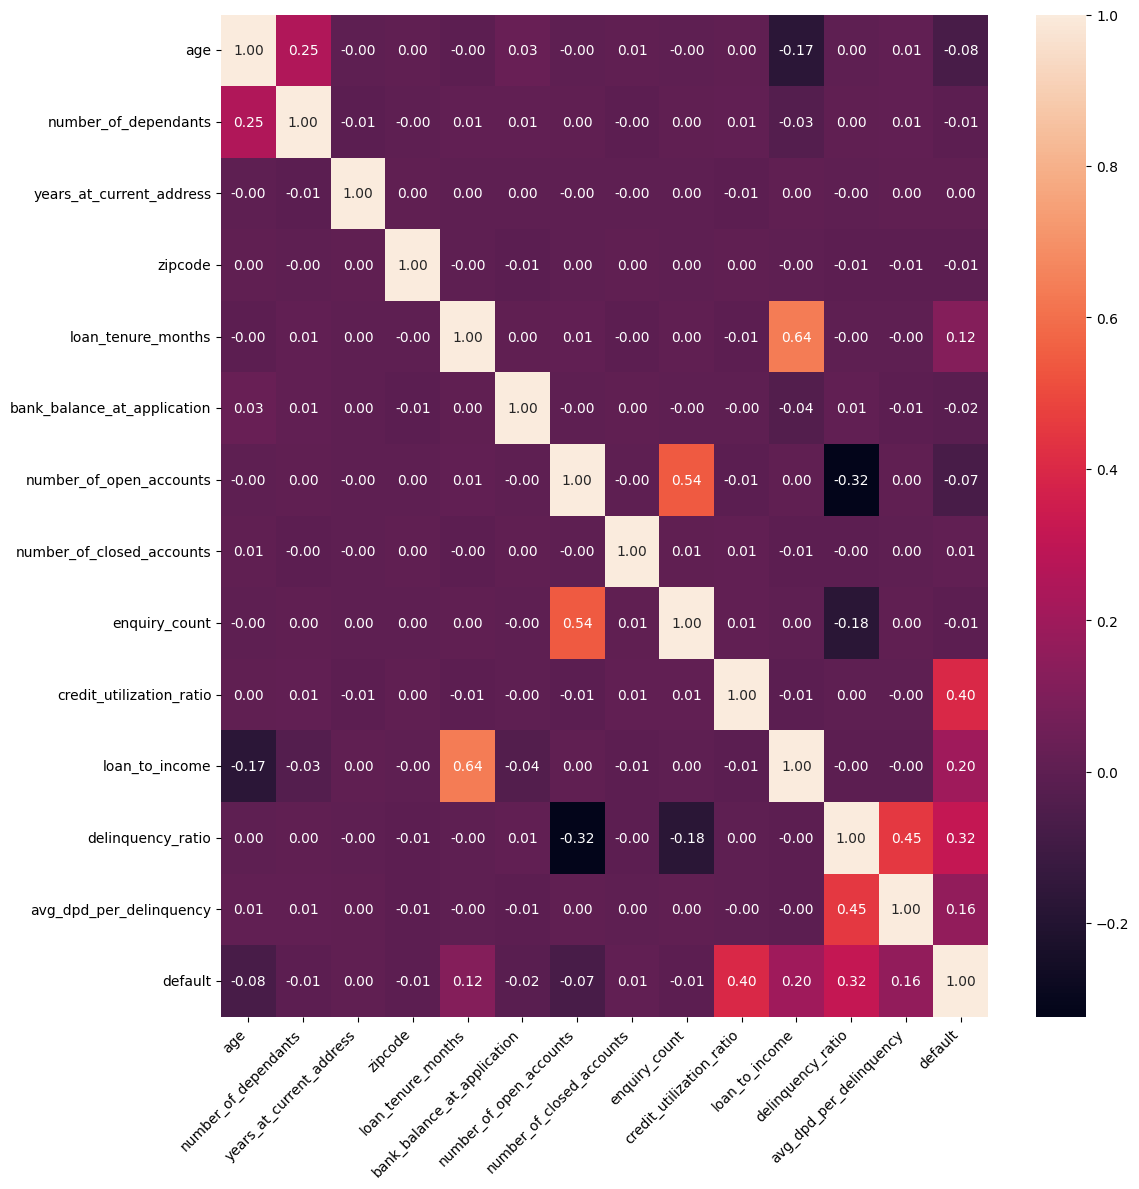

In [60]:
plt.figure(figsize=(12,12))
cm = df_train_3[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature Selection: Categorical Features

In [61]:
X_train_1.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_type,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
12746,0.79,M,Married,Self-Employed,0.60,Owned,0.97,Hyderabad,Telangana,0.66,...,Secured,0.42,0.61,1.00,1.00,0.38,0.36,0.41,0.13,0.59
32495,0.50,F,Single,Salaried,0.00,Owned,0.87,Mumbai,Maharashtra,0.49,...,Secured,0.83,0.03,0.67,0.50,0.50,0.05,0.31,0.06,0.62
43675,0.38,M,Single,Salaried,0.00,Mortgage,0.83,Chennai,Tamil Nadu,0.83,...,Secured,0.49,0.17,0.00,0.50,0.38,0.00,0.76,0.22,0.56
9040,0.46,M,Married,Salaried,0.40,Mortgage,0.97,Bangalore,Karnataka,0.76,...,Secured,0.64,0.08,0.67,0.00,0.88,0.88,0.19,0.00,0.00
13077,0.77,M,Married,Self-Employed,0.80,Owned,0.93,Pune,Maharashtra,0.51,...,Unsecured,0.17,0.07,0.00,1.00,0.00,0.72,0.05,0.00,0.00


### Calculate WOE and IV

In [62]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)

    total_iv = grouped['iv'].sum()

    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,0.08
Education,5620,559,5061,0.17,0.15,0.16,0.00
Home,11304,1734,9570,0.54,0.28,0.66,0.17
Personal,13117,603,12514,0.19,0.37,-0.67,0.12


In [63]:
X_train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  float64
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  float64
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  float64
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  float64
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  loan_tenure_months           37488 non-null  float64
 13  bank_balance_at_a

In [64]:
iv_values = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), feature, 'default' )
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train],axis=1), feature, 'default' )
    iv_values[feature] = iv

iv_values

{'age': np.float64(0.0890689462679479),
 'gender': np.float64(0.00047449502170914947),
 'marital_status': np.float64(0.001129766845390142),
 'employment_status': np.float64(0.003953046301722585),
 'number_of_dependants': np.float64(0.0019380899135053508),
 'residence_type': np.float64(0.246745268718145),
 'years_at_current_address': np.float64(0.0020800513608156363),
 'city': np.float64(0.0019059578709781529),
 'state': np.float64(0.0019005589806779287),
 'zipcode': np.float64(0.0016677413243392572),
 'loan_purpose': np.float64(0.3691197842282755),
 'loan_type': np.float64(0.16319324904149224),
 'loan_tenure_months': np.float64(0.21893515090196278),
 'bank_balance_at_application': np.float64(0.0063187993277516365),
 'number_of_open_accounts': np.float64(0.08463134083005877),
 'number_of_closed_accounts': np.float64(0.0011964272592421567),
 'enquiry_count': np.float64(0.007864214085342608),
 'credit_utilization_ratio': np.float64(2.352965568168245),
 'loan_to_income': np.float64(0.47641

In [65]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.353
19,delinquency_ratio,0.717
18,loan_to_income,0.476
20,avg_dpd_per_delinquency,0.402
10,loan_purpose,0.369
5,residence_type,0.247
12,loan_tenure_months,0.219
11,loan_type,0.163
0,age,0.089
14,number_of_open_accounts,0.085


In [66]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

### Feature Encoding

In [67]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [68]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True).astype(float)
X_train_encoded.head(3)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.788,0.415,1.000,0.364,0.415,0.132,0.590,1.000,0.000,0.000,1.000,0.000,0.000
32495,0.500,0.830,0.667,0.051,0.307,0.062,0.620,1.000,0.000,1.000,0.000,0.000,0.000
43675,0.385,0.491,0.000,0.000,0.759,0.222,0.560,0.000,0.000,0.000,1.000,0.000,0.000


In [69]:
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True).astype(float)
X_test_encoded.head(3)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000
30367,0.231,0.547,0.667,0.828,0.180,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000


<h3 align="center" style="color:blue">Model Training</h3>

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report



In [71]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

,count
default,
0,34195
1,34195


In [72]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

Attempt:
Implement Gaussian Naive Bayes from scratch
Handle Class Imbalance Using SMOTE Tomek

## Gaussian Naive Bayes – Logic and Formulas

Goal:
Classify a sample x into the class C that maximizes the posterior probability.

1. Bayes Theorem
   P(C | x) = ( P(x | C) * P(C) ) / P(x)

For classification we use:
P(C | x) ∝ P(x | C) * P(C)

because P(x) is the same for all classes.

---

2. Prior Probability
   Probability of a class before seeing the data.

P(C) = (# samples in class C) / (total samples)

Computed in code as:
prior = len(X_c) / len(X)

---

3. Naive Independence Assumption
   Features are assumed conditionally independent given the class.

P(x | C) = Π_i P(x_i | C)

where x = (x1, x2, ..., xn)

---

4. Gaussian Likelihood
   Each feature is assumed to follow a normal (Gaussian) distribution.

P(x_i | C) =
(1 / sqrt(2πσ_i^2)) * exp(-(x_i - μ_i)^2 / (2σ_i^2))

where
μ_i = mean of feature i in class C
σ_i^2 = variance of feature i in class C

---

5. Log Transformation (for numerical stability)

Instead of multiplying probabilities:

log P(C | x) =
log P(C) + Σ_i log P(x_i | C)

This prevents numerical underflow.

---

6. Decision Rule (Prediction)

Choose the class with the maximum posterior probability:

C_hat = argmax_C [ log P(C) + Σ_i log P(x_i | C) ]

---

7. Probability Prediction

Convert log-posteriors to probabilities using exponentiation
and normalization:

p_i = exp(log_p_i - max(log_p))

Normalize:

P_i = p_i / Σ p_i

This ensures probabilities sum to 1.


---
## 📚 Base Model — Formula & Syllabus Explanation

### Syllabus: Module 1 — Random Variables, Gaussian Distribution, Density Functions, Bayes Theorem

The `GaussianNaiveBayes` class below implements the following formulas from scratch:

---

### 1. Prior Probability
**Formula:** `P(C) = (samples in class C) / (total samples)`  
**In code:** `'prior': len(X_c) / len(X)`  
**Syllabus:** Module 1 — Random Variables. The prior is the marginal probability of each class.

---

### 2. Gaussian Likelihood — Per Feature
Each feature is assumed to follow a Normal distribution within each class:

```
P(xi | C) = (1 / sqrt(2π σ²))  ×  exp( −(xi − μ)² / (2σ²) )
```

**In code (`_pdf` method):**
```python
numerator   = np.exp(-((x - mean) ** 2) / (2 * variance))
denominator = np.sqrt(2 * np.pi * variance)
return numerator / denominator
```
**Syllabus:** Module 1 — *"Distribution and Density — Statistical Independence"*. This is the exact Gaussian PDF formula.

---

### 3. Naive Independence Assumption
Features are assumed conditionally independent, so:

```
P(x | C) = P(x1|C) × P(x2|C) × ... × P(xn|C)
```

This is the "Naive" assumption — it ignores all correlations. Extensions 2 and 3 fix this.

---

### 4. Log-Sum Trick (Numerical Stability)
Multiplying many small probabilities causes underflow. Log converts it to a sum:

```
log P(C | x)  =  log P(C)  +  Σ log P(xi | C)
```

**In code (`_calculate_log_posteriors`):**
```python
prior      = np.log(self.parameters[c]['prior'])
likelihood = np.sum(np.log(self._pdf(c, x)))
```
**Syllabus:** Module 1 — *"Density of Functions of Random Variables"*

---

### 5. Decision Rule
```
C_hat = argmax_C [ log P(C) + Σ log P(xi | C) ]
```
**In code:** `self.classes[np.argmax(self._calculate_log_posteriors(x))]`

---

### 6. Probability Output (Softmax normalisation)
```
p_i = exp(log_post_i − max(log_posts))
P_i = p_i / Σ p_j
```
**In code (`predict_proba`):**
```python
exp_log_posteriors = np.exp(log_posteriors - np.max(log_posteriors))
probabilities.append(exp_log_posteriors / np.sum(exp_log_posteriors))
```
Subtracting the max before `exp()` prevents numerical overflow.


In [73]:
import numpy as np
from scipy.stats import norm
from sklearn.metrics import classification_report

class GaussianNaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.parameters = {}
        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.parameters[c] = {
                'prior': len(X_c) / len(X),
                'mean': X_c.mean(axis=0).values, # Convert to numpy array
                'variance': X_c.var(axis=0).values # Convert to numpy array
            }

    def _pdf(self, class_idx, x):
        mean = self.parameters[class_idx]['mean']
        variance = self.parameters[class_idx]['variance']
        # Add a small epsilon to variance to avoid division by zero
        variance = np.where(variance == 0, 1e-9, variance)
        numerator = np.exp(-((x - mean) ** 2) / (2 * variance))
        denominator = np.sqrt(2 * np.pi * variance)
        return numerator / denominator

    def _calculate_log_posteriors(self, x):
        log_posteriors = []
        x = np.asarray(x, dtype=float)
        for c in self.classes:
            prior = np.log(self.parameters[c]['prior'])
            likelihood = np.sum(np.log(self._pdf(c, x)))
            log_posteriors.append(prior + likelihood)
        return log_posteriors

    def predict(self, X):
        y_pred = [self.classes[np.argmax(self._calculate_log_posteriors(x))] for x in X.values]
        return np.array(y_pred)

    def predict_proba(self, X):
        probabilities = []
        for x_sample in X.values:
            log_posteriors = self._calculate_log_posteriors(x_sample)
            # Convert log-posteriors to probabilities and normalize
            exp_log_posteriors = np.exp(log_posteriors - np.max(log_posteriors)) # Subtract max for numerical stability
            probabilities.append(exp_log_posteriors / np.sum(exp_log_posteriors))
        return np.array(probabilities)

In [74]:
model_gnb = GaussianNaiveBayes()
model_gnb.fit(X_train_smt, y_train_smt)

# Make predictions on the test set
y_pred_gnb = model_gnb.predict(X_test_encoded)

# Evaluate the model
print("Classification Report for Custom Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))

Classification Report for Custom Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     11423
           1       0.34      0.88      0.49      1074

    accuracy                           0.84     12497
   macro avg       0.66      0.86      0.70     12497
weighted avg       0.93      0.84      0.87     12497



## Model Evaluation : ROC/AUC

In [75]:
y_pred = model_gnb.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     11423
           1       0.34      0.88      0.49      1074

    accuracy                           0.84     12497
   macro avg       0.66      0.86      0.70     12497
weighted avg       0.93      0.84      0.87     12497



In [76]:
from sklearn.metrics import roc_curve

probabilities = model_gnb.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00008754, 0.00008754]),
 array([0.        , 0.0009311 , 0.03351955, 0.03351955, 0.03631285]),
 array([       inf, 1.        , 0.99999996, 0.99999995, 0.99999994]))

In [77]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

np.float64(0.9385505019358017)

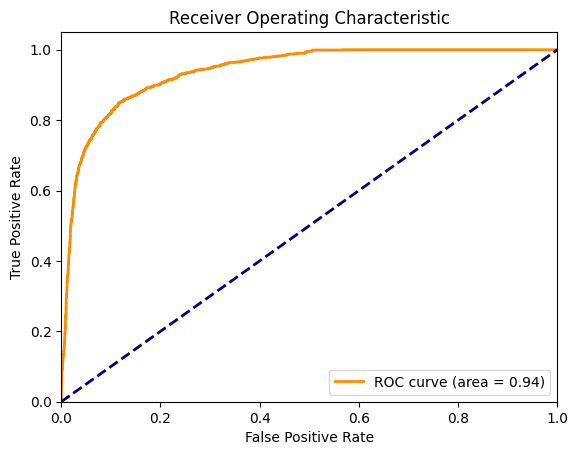

In [78]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Model Evaluation : Rankordering, KS statistic, Gini coeff

In [79]:
probabilities = model_gnb.predict_proba(X_test_encoded)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})
df_eval.head(3)

,Default Truth,Default Probability
19205,0,0.867
15514,0,0.002
30367,0,0.141


In [80]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
df_eval.head(3)

,Default Truth,Default Probability,Decile
19205,0,0.867,8
15514,0,0.002,2
30367,0,0.141,6


In [81]:
df_eval[df_eval.Decile==8]['Default Probability'].describe()

,Default Probability
count,1250.000
mean,0.772
std,0.093
min,0.594
25%,0.692
50%,0.782
75%,0.858
max,0.909


In [82]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),
}))
df_decile.reset_index(inplace=True)
df_decile

/tmp/ipykernel_775/482895170.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({


,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.001,0.000,1250.000
2,2,0.001,0.003,0.000,1249.000
3,3,0.003,0.008,1.000,1249.000
4,4,0.008,0.026,16.000,1234.000
5,5,0.026,0.079,22.000,1227.000
6,6,0.079,0.244,36.000,1214.000
7,7,0.244,0.593,70.000,1179.000
8,8,0.594,0.909,178.000,1072.000
9,9,0.910,1.000,751.000,499.000


In [83]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.001,0.000,1250.000,0.000,100.000
2,2,0.001,0.003,0.000,1249.000,0.000,100.000
3,3,0.003,0.008,1.000,1249.000,0.080,99.920
4,4,0.008,0.026,16.000,1234.000,1.280,98.720
5,5,0.026,0.079,22.000,1227.000,1.761,98.239
6,6,0.079,0.244,36.000,1214.000,2.880,97.120
7,7,0.244,0.593,70.000,1179.000,5.604,94.396
8,8,0.594,0.909,178.000,1072.000,14.240,85.760
9,9,0.910,1.000,751.000,499.000,60.080,39.920


In [84]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.910,1.000,751.000,499.000,60.080,39.920
1,8,0.594,0.909,178.000,1072.000,14.240,85.760
2,7,0.244,0.593,70.000,1179.000,5.604,94.396
3,6,0.079,0.244,36.000,1214.000,2.880,97.120
4,5,0.026,0.079,22.000,1227.000,1.761,98.239
5,4,0.008,0.026,16.000,1234.000,1.280,98.720
6,3,0.003,0.008,1.000,1249.000,0.080,99.920
7,2,0.001,0.003,0.000,1249.000,0.000,100.000
8,1,0.000,0.001,0.000,1250.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [85]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.910,1.000,751.000,499.000,60.080,39.920,751.000,499.000
1,8,0.594,0.909,178.000,1072.000,14.240,85.760,929.000,1571.000
2,7,0.244,0.593,70.000,1179.000,5.604,94.396,999.000,2750.000
3,6,0.079,0.244,36.000,1214.000,2.880,97.120,1035.000,3964.000
4,5,0.026,0.079,22.000,1227.000,1.761,98.239,1057.000,5191.000
5,4,0.008,0.026,16.000,1234.000,1.280,98.720,1073.000,6425.000
6,3,0.003,0.008,1.000,1249.000,0.080,99.920,1074.000,7674.000
7,2,0.001,0.003,0.000,1249.000,0.000,100.000,1074.000,8923.000
8,1,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,10173.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000


In [86]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.910,1.000,751.000,499.000,60.080,39.920,751.000,499.000,69.926,4.368
1,8,0.594,0.909,178.000,1072.000,14.240,85.760,929.000,1571.000,86.499,13.753
2,7,0.244,0.593,70.000,1179.000,5.604,94.396,999.000,2750.000,93.017,24.074
3,6,0.079,0.244,36.000,1214.000,2.880,97.120,1035.000,3964.000,96.369,34.702
4,5,0.026,0.079,22.000,1227.000,1.761,98.239,1057.000,5191.000,98.417,45.443
5,4,0.008,0.026,16.000,1234.000,1.280,98.720,1073.000,6425.000,99.907,56.246
6,3,0.003,0.008,1.000,1249.000,0.080,99.920,1074.000,7674.000,100.000,67.180
7,2,0.001,0.003,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114
8,1,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000


In [87]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.910,1.000,751.000,499.000,60.080,39.920,751.000,499.000,69.926,4.368,65.557
1,8,0.594,0.909,178.000,1072.000,14.240,85.760,929.000,1571.000,86.499,13.753,72.746
2,7,0.244,0.593,70.000,1179.000,5.604,94.396,999.000,2750.000,93.017,24.074,68.943
3,6,0.079,0.244,36.000,1214.000,2.880,97.120,1035.000,3964.000,96.369,34.702,61.667
4,5,0.026,0.079,22.000,1227.000,1.761,98.239,1057.000,5191.000,98.417,45.443,52.974
5,4,0.008,0.026,16.000,1234.000,1.280,98.720,1073.000,6425.000,99.907,56.246,43.661
6,3,0.003,0.008,1.000,1249.000,0.080,99.920,1074.000,7674.000,100.000,67.180,32.820
7,2,0.001,0.003,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114,21.886
8,1,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057,10.943
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000,0.000


The decile analysis shows that the model effectively ranks borrowers by risk. The highest-risk decile (Decile 9) contains the majority of events with an event rate of about 60%, while lower deciles show progressively smaller event rates. The cumulative event rate rises rapidly in the top deciles, indicating that most risky customers are captured early. The KS statistic peaks around **72.7**, suggesting strong separation between events and non-events and good discriminatory power of the model.


In [88]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9385505019358017
Gini Coefficient: 0.8771010038716034


AUC of 0.93: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.87: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.



#### Finalize The Model and Visualize Feature Importance

In [89]:
final_model = model_gnb


In [90]:
feature_names = X_train_encoded.columns
class_params = {}

for c in final_model.classes:
    class_params[c] = pd.DataFrame({
        'mean': final_model.parameters[c]['mean'],
        'std': np.sqrt(final_model.parameters[c]['variance'])
    }, index=feature_names)

print("Parameters for Class 0 (Non-Default):")
display(class_params[0].transpose())

print("\nParameters for Class 1 (Default):")
display(class_params[1].transpose())

Parameters for Class 0 (Non-Default):


,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
mean,0.419,0.368,0.509,0.402,0.280,0.087,0.314,0.584,0.182,0.148,0.279,0.365,0.365
std,0.190,0.233,0.371,0.276,0.220,0.143,0.291,0.493,0.386,0.355,0.449,0.482,0.482



Parameters for Class 1 (Default):


,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
mean,0.366,0.472,0.410,0.828,0.446,0.278,0.479,0.367,0.373,0.173,0.544,0.183,0.183
std,0.163,0.224,0.381,0.214,0.250,0.301,0.226,0.482,0.484,0.378,0.498,0.386,0.386


**Interpretation:**

For each feature, compare the 'mean' and 'std' (standard deviation) values between Class 0 and Class 1.

*   **Features with larger differences in means** between the two classes are generally more discriminative.
*   **Features with smaller standard deviations** (indicating less spread) can be more powerful if their means are also well-separated.



/tmp/ipykernel_775/551723912.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean Difference', y='Feature', data=importance_df, palette='viridis') # Use 'Feature' for y-axis


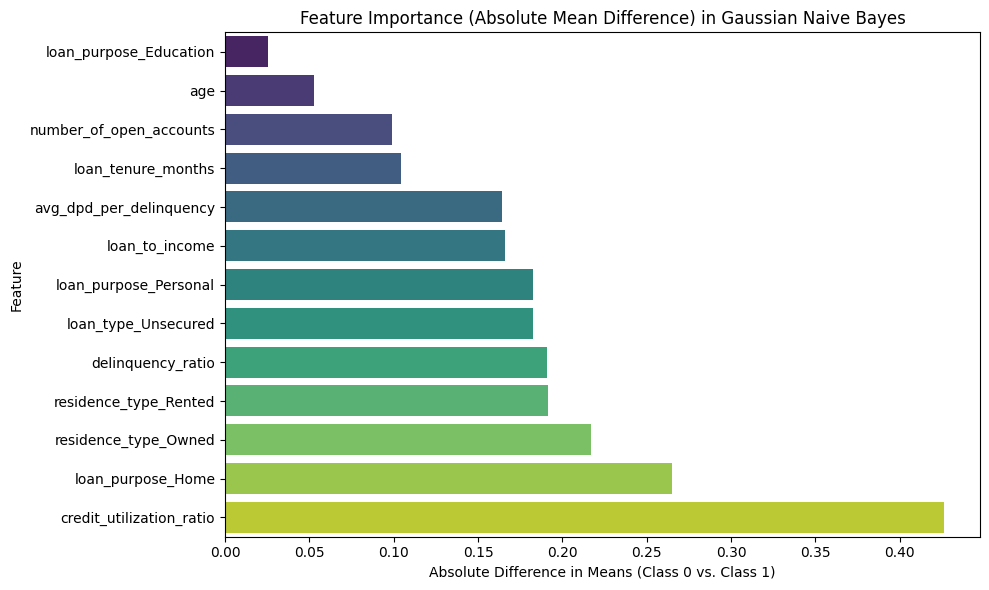

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the absolute difference in means between Class 0 and Class 1 for each feature
mean_diff = abs(class_params[0]['mean'] - class_params[1]['mean'])

# Create a DataFrame for easier handling and sorting
importance_df = mean_diff.reset_index()
importance_df.columns = ['Feature', 'Mean Difference'] # Rename columns for clarity

# Sort the features by their absolute mean difference for better visualization
importance_df = importance_df.sort_values(by='Mean Difference', ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Mean Difference', y='Feature', data=importance_df, palette='viridis') # Use 'Feature' for y-axis
plt.xlabel('Absolute Difference in Means (Class 0 vs. Class 1)')
plt.ylabel('Feature')
plt.title('Feature Importance (Absolute Mean Difference) in Gaussian Naive Bayes')
plt.tight_layout()
plt.show()

In [92]:
print("Displaying importance_df before plotting:")
display(importance_df)

Displaying importance_df before plotting:


,Feature,Mean Difference
9,loan_purpose_Education,0.025
0,age,0.053
2,number_of_open_accounts,0.099
1,loan_tenure_months,0.104
6,avg_dpd_per_delinquency,0.164
4,loan_to_income,0.166
11,loan_purpose_Personal,0.183
12,loan_type_Unsecured,0.183
5,delinquency_ratio,0.191
8,residence_type_Rented,0.191


### Save the Model

In [93]:
X_test_encoded.head(2)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000


In [94]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [95]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [96]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

---
## 📚 Extension 1 — Formula & Syllabus Explanation

### Syllabus: Module 1 — Density Functions, Gaussian Distribution, Statistical Independence

### Why this is needed
The base GNB model **assumes** every feature follows a Gaussian distribution within each class — but it never verifies this. Extension 1 is the **diagnostic step** that checks whether the assumption actually holds, feature by feature.

---

### What is KL Divergence?

KL Divergence measures how different one probability distribution is from another. Here:

```
KL(P || Q) = Σ  P(x) × log( P(x) / Q(x) )
```

- **P** = empirical histogram of the feature (what the data actually looks like)
- **Q** = fitted Gaussian PDF using the same mean and std (what GNB assumes)
- **Lower KL = closer to Gaussian = GNB assumption is valid**

---

### In the code

```python
mu, sigma = data.mean(), data.std()
q = norm.pdf(bin_centers, mu, sigma)   # Gaussian PDF — Module 1 formula

p /= p.sum()    # normalise empirical histogram
q /= q.sum()    # normalise Gaussian
return np.sum(kl_div(p, q))           # scipy computes p * log(p/q) per bin
```

`norm.pdf` evaluates the exact Gaussian density formula from Module 1 at each histogram bin.

---

### How to interpret KL scores

| KL Divergence | Meaning | Impact on GNB |
|---|---|---|
| < 0.05 | Feature is very Gaussian | Assumption valid — model is reliable for this feature |
| 0.05 – 0.20 | Slight non-Gaussianity | Minor inaccuracy in likelihood estimates |
| > 0.20 | Skewed or multimodal | Assumption violated — this feature hurts GNB accuracy |

Features with high KL divergence motivate using the **Multivariate Gaussian Bayes** (Extension 2) or **PCA** (Extension 3) which are less sensitive to the shape of individual feature distributions.

**Syllabus link:** Module 1 — *"Distribution and Density — Statistical Independence"*. KL Divergence directly measures the gap between the theoretical Gaussian density (Module 1) and the empirical data distribution.


<h3 align='center' style='color:blue'>Extension 1 – Validate Gaussian Assumption</h3>

### Why this matters
Gaussian Naive Bayes assumes each feature follows a **Normal (Gaussian) distribution** within each class.  
Here we verify that assumption empirically by:
1. Plotting the **empirical PDF vs fitted Gaussian PDF** for each feature  
2. Computing the **KL Divergence** between them — the lower the value, the better the Gaussian fits

**KL Divergence formula:**  
`KL(P || Q) = Σ P(x) * log(P(x) / Q(x))`  
where P = empirical distribution, Q = fitted Gaussian

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import kl_div

# Use the numeric columns from the training set (after SMOTE)
numeric_cols = X_train_smt.select_dtypes(include=[np.number]).columns.tolist()

def kl_divergence_gaussian(data):
    """Compute KL divergence between empirical histogram and fitted Gaussian."""
    mu, sigma = data.mean(), data.std()
    if sigma == 0:
        return np.nan
    counts, bin_edges = np.histogram(data, bins=30, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    q = norm.pdf(bin_centers, mu, sigma)
    # Clip to avoid log(0)
    p = np.clip(counts, 1e-10, None)
    q = np.clip(q, 1e-10, None)
    p /= p.sum()
    q /= q.sum()
    return np.sum(kl_div(p, q))

kl_scores = {}
for col in numeric_cols:
    kl_scores[col] = kl_divergence_gaussian(X_train_smt[col])

kl_df = (
    pd.DataFrame(list(kl_scores.items()), columns=['Feature', 'KL Divergence'])
    .sort_values('KL Divergence')
    .reset_index(drop=True)
)
print("KL Divergence (lower = closer to Gaussian):")
display(kl_df)


KL Divergence (lower = closer to Gaussian):


,Feature,KL Divergence
0,age,0.021
1,loan_tenure_months,0.061
2,loan_to_income,0.290
3,credit_utilization_ratio,0.338
4,delinquency_ratio,0.668
5,avg_dpd_per_delinquency,0.901
6,number_of_open_accounts,2.132
7,loan_purpose_Education,2.926
8,loan_type_Unsecured,3.005
9,loan_purpose_Personal,3.005


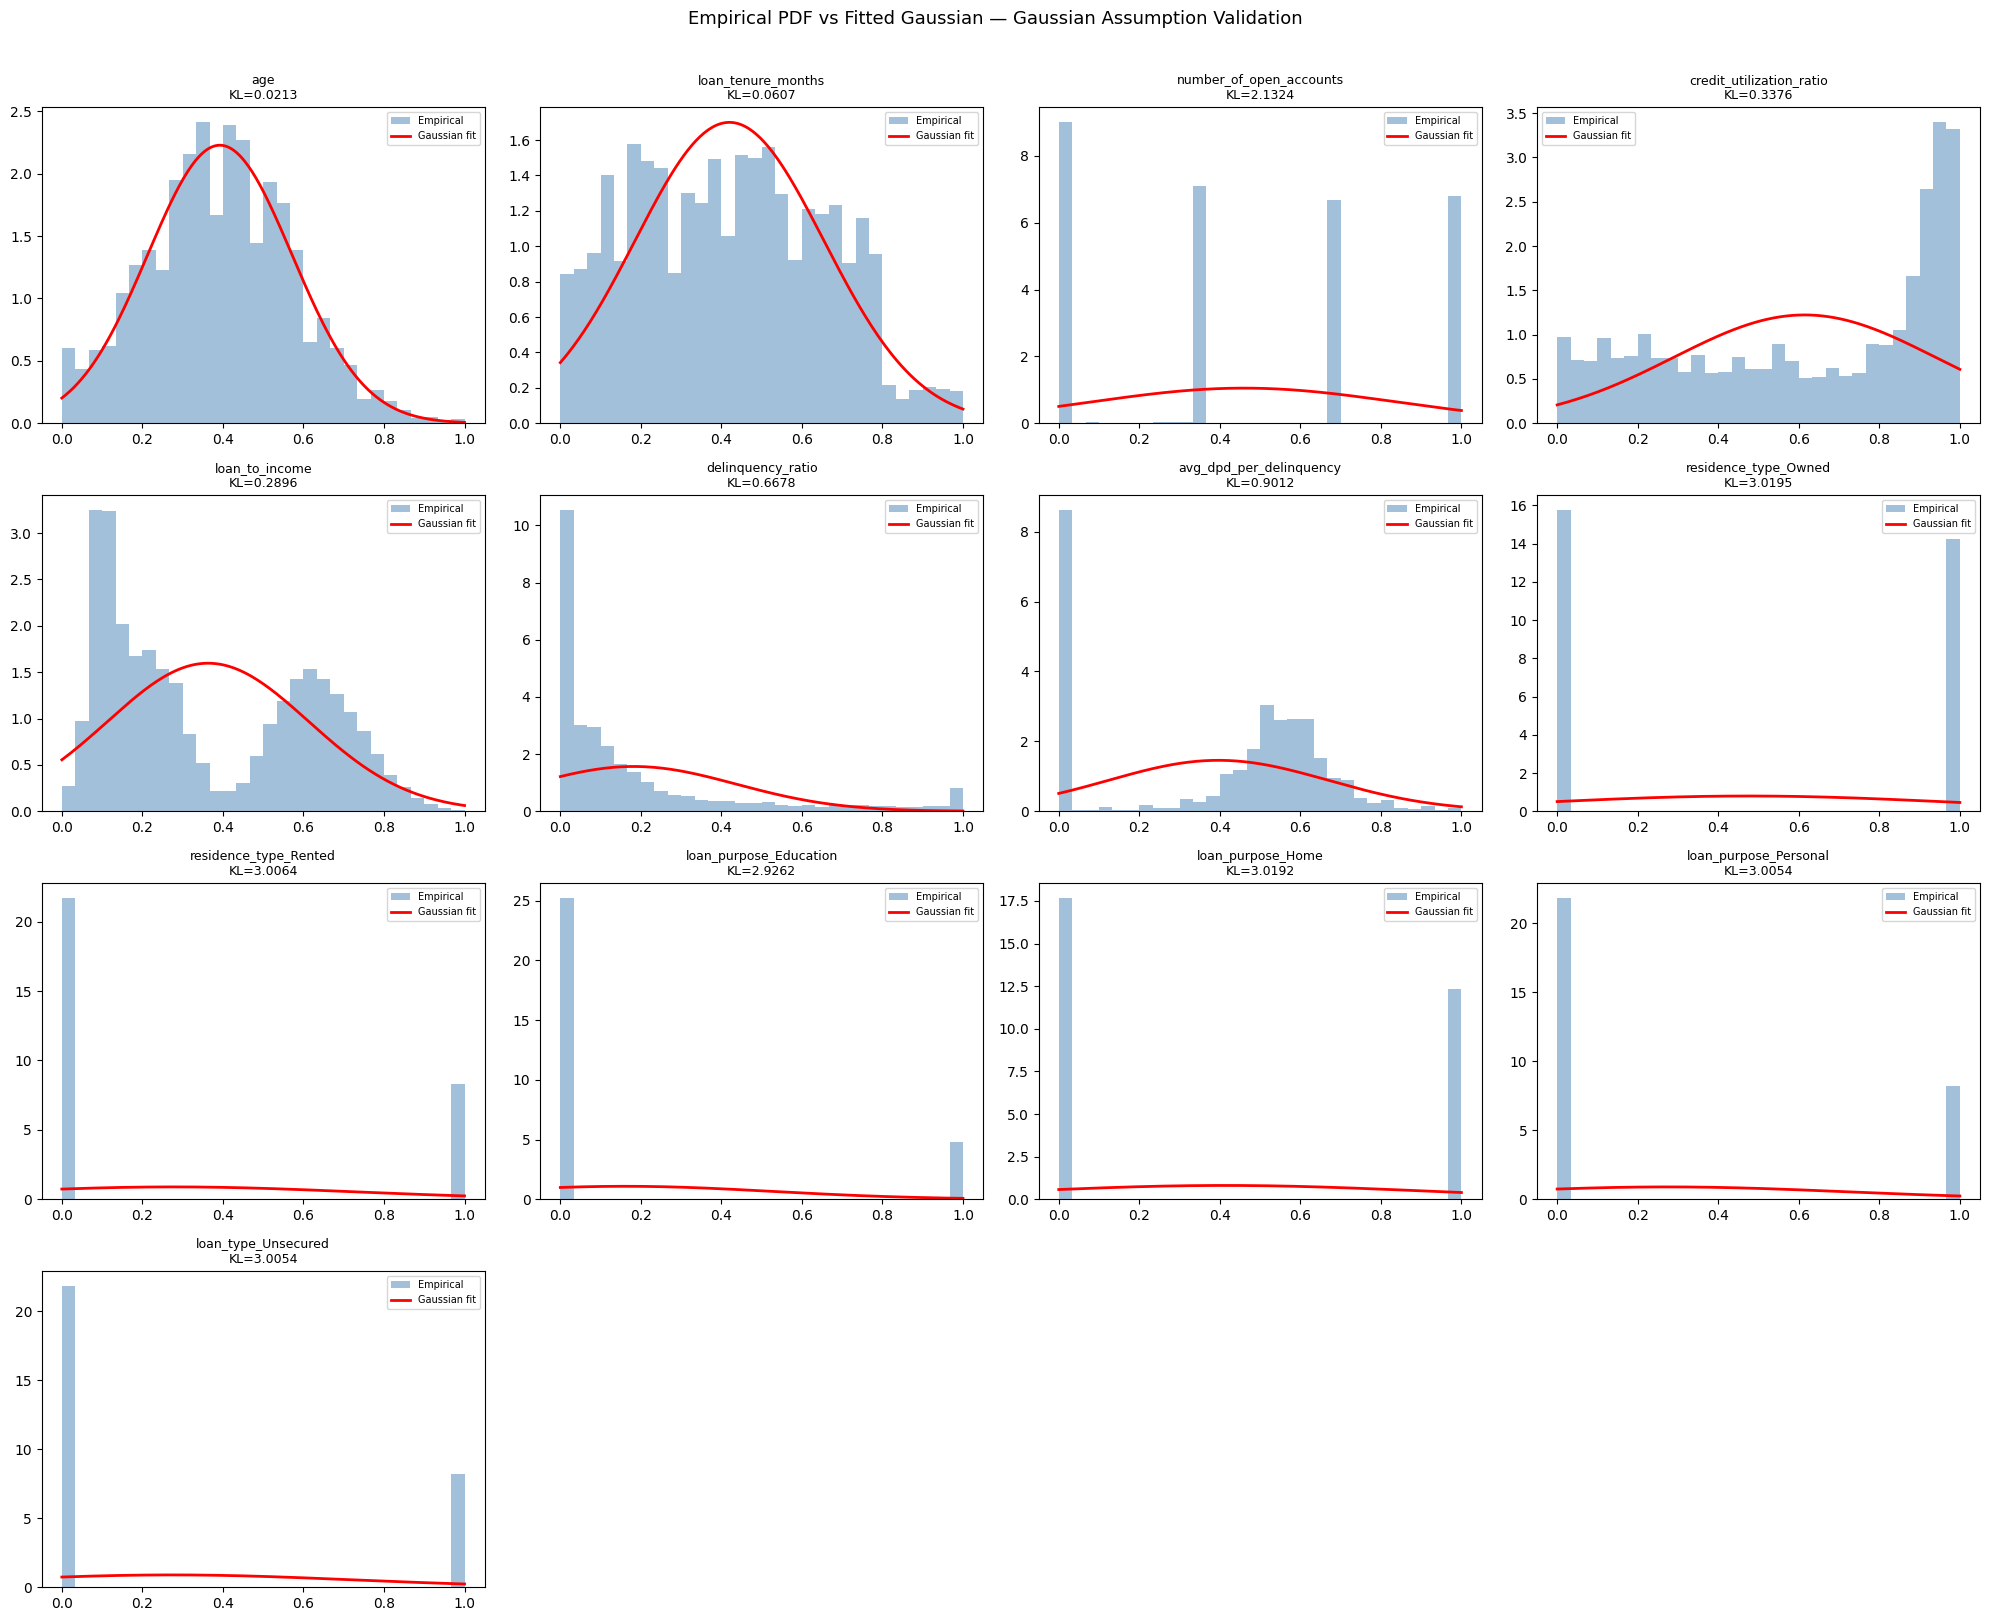

In [99]:
# Plot empirical vs Gaussian PDF for each numeric feature
n = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = X_train_smt[col].dropna()
    mu, sigma = data.mean(), data.std()
    x_range = np.linspace(data.min(), data.max(), 200)

    axes[i].hist(data, bins=30, density=True, alpha=0.5, color='steelblue', label='Empirical')
    axes[i].plot(x_range, norm.pdf(x_range, mu, sigma), 'r-', lw=2, label='Gaussian fit')
    kl = kl_scores.get(col, np.nan)
    axes[i].set_title(f"{col}\nKL={kl:.4f}", fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Empirical PDF vs Fitted Gaussian — Gaussian Assumption Validation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Insights**  
- Features with **low KL divergence** (< 0.05) fit the Gaussian assumption well — the model is reliable for those.  
- Features with **high KL divergence** are non-Gaussian (skewed / multimodal). The independence assumption may hurt accuracy for those.  
- This motivates either a **Multivariate Gaussian** (to capture correlations) or **transformations** before fitting.

---
## 📚 Extension 2 — Formula & Syllabus Explanation

### Syllabus: Module 2 — Jointly Gaussian Random Variables, Covariance Matrix, Joint Central Moments, Transformations of Multiple Random Variables

### Problem with GNB
GNB uses only **per-feature variances** — it completely ignores correlations between features. In credit risk data, features like `loan_amount`, `sanction_amount`, and `net_disbursement` are clearly related. GNB treats them as if they were independent, which leads to inaccurate likelihood estimates.

### The fix: Full Covariance Matrix
Instead of one variance σ² per feature, this extension computes the full **d × d covariance matrix Σ** per class.

---

### Step 1 — Covariance Matrix per class

```
Σ_c[i,j] = E[ (Xi − μi)(Xj − μj) ]
```

```python
mu    = X_c.mean(axis=0)       # mean vector (d,)
sigma = np.cov(X_c.T)          # covariance matrix (d × d)
sigma += 1e-6 * np.eye(...)    # regularisation — ensures Σ is invertible
```

**Diagonal entries** = variance of each individual feature (same as GNB)  
**Off-diagonal entries** = covariance between pairs of features (ignored by GNB)

**Syllabus link:** Module 2 — *"Joint Central Moments"* and *"Covariance Functions"*

---

### Step 2 — Multivariate Gaussian PDF

```
p(x | C) = 1 / ((2π)^(d/2) |Σ|^(1/2))  ×  exp( −½ (x−μ)ᵀ Σ⁻¹ (x−μ) )
```

```python
d     = len(x)
diff  = x - p['mean']                       # (x − μ)
mahal = diff @ p['cov_inv'] @ diff          # (x−μ)ᵀ Σ⁻¹ (x−μ)  — Mahalanobis distance²
return -0.5 * (d * np.log(2*np.pi) + p['log_det'] + mahal)
```

**Syllabus link:** Module 2 — *"Jointly Gaussian Random Variables"* — this is the exact multivariate Gaussian PDF studied in that topic.

---

### Mahalanobis Distance vs GNB

| | GNB | Multivariate Gaussian Bayes |
|---|---|---|
| Distance measure | Σ (xi−μi)² / σi² | (x−μ)ᵀ Σ⁻¹ (x−μ) |
| What it accounts for | Feature scale only | Feature scale AND correlations |
| Covariance used | Diagonal only | Full d×d matrix |

The Mahalanobis distance stretches and rotates the feature space according to the covariance — so correlated, high-variance features are appropriately handled.

---

### Step 3 — Precompute Σ⁻¹ and log|Σ|
```python
'cov_inv': np.linalg.inv(sigma)          # inverse — used in Mahalanobis distance
'log_det': np.log(np.linalg.det(sigma))  # log determinant — normalisation constant
```
Both are computed once during `fit()` and reused for every prediction.

**Syllabus link:** Module 2 — *"Transformations of Multiple Random Variables"* — the inverse and determinant of the covariance matrix are the key quantities in the multivariate Gaussian transformation.


<h3 align='center' style='color:blue'>Extension 2 – Multivariate Gaussian Bayes Classifier</h3>

### Removing the independence assumption
Naive Bayes assumes features are **conditionally independent**, using per-feature variances only.  
The **Multivariate Gaussian** uses the full **covariance matrix** Σ:

$$p(\mathbf{x} \mid C) = \frac{1}{(2\pi)^{d/2} |\Sigma_C|^{1/2}} \exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_C)^\top \Sigma_C^{-1} (\mathbf{x}-\boldsymbol{\mu}_C)\right)$$

This captures **inter-feature correlations** (covariances), not just variances.  
**Syllabus link:** Joint Gaussian distribution, covariance matrix, joint moments (Module 2).

In [100]:
class MultivariateGaussianBayes:
    """
    Bayesian classifier using the full multivariate Gaussian likelihood.
    Replaces the diagonal variance (Naive assumption) with the full covariance matrix.
    """
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y)
        self.classes_ = np.unique(y)
        self.params_ = {}

        for c in self.classes_:
            X_c = X[y == c]
            mu = X_c.mean(axis=0)                          # mean vector  (d,)
            sigma = np.cov(X_c.T)                          # covariance   (d, d)
            # Regularise: add small λI to ensure invertibility
            sigma += 1e-6 * np.eye(sigma.shape[0])
            self.params_[c] = {
                'prior': np.log(len(X_c) / len(X)),        # log prior
                'mean':  mu,
                'cov':   sigma,
                'cov_inv': np.linalg.inv(sigma),
                'log_det': np.log(np.linalg.det(sigma))
            }

    def _log_likelihood(self, c, x):
        """log N(x; mu_c, Sigma_c)"""
        p = self.params_[c]
        d = len(x)
        diff = x - p['mean']
        mahal = diff @ p['cov_inv'] @ diff          # Mahalanobis distance²
        return -0.5 * (d * np.log(2 * np.pi) + p['log_det'] + mahal)

    def predict(self, X):
        X = np.array(X, dtype=float)
        preds = []
        for x in X:
            scores = {c: self.params_[c]['prior'] + self._log_likelihood(c, x)
                      for c in self.classes_}
            preds.append(max(scores, key=scores.get))
        return np.array(preds)

    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        proba = []
        for x in X:
            log_posts = np.array([self.params_[c]['prior'] + self._log_likelihood(c, x)
                                  for c in self.classes_])
            log_posts -= log_posts.max()             # numeric stability
            exp_p = np.exp(log_posts)
            proba.append(exp_p / exp_p.sum())
        return np.array(proba)


In [101]:
# Train Multivariate Gaussian Bayes
model_mvg = MultivariateGaussianBayes()
model_mvg.fit(X_train_smt.values, y_train_smt.values)

y_pred_mvg = model_mvg.predict(X_test_encoded.values)
print("Classification Report — Multivariate Gaussian Bayes:")
print(classification_report(y_test, y_pred_mvg))

prob_mvg = model_mvg.predict_proba(X_test_encoded.values)[:, 1]
fpr_mvg, tpr_mvg, _ = roc_curve(y_test, prob_mvg)
auc_mvg = auc(fpr_mvg, tpr_mvg)
print(f"AUC (Multivariate Gaussian Bayes): {auc_mvg:.4f}")


Classification Report — Multivariate Gaussian Bayes:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     11423
           1       0.50      0.93      0.65      1074

    accuracy                           0.91     12497
   macro avg       0.74      0.92      0.80     12497
weighted avg       0.95      0.91      0.92     12497

AUC (Multivariate Gaussian Bayes): 0.9690


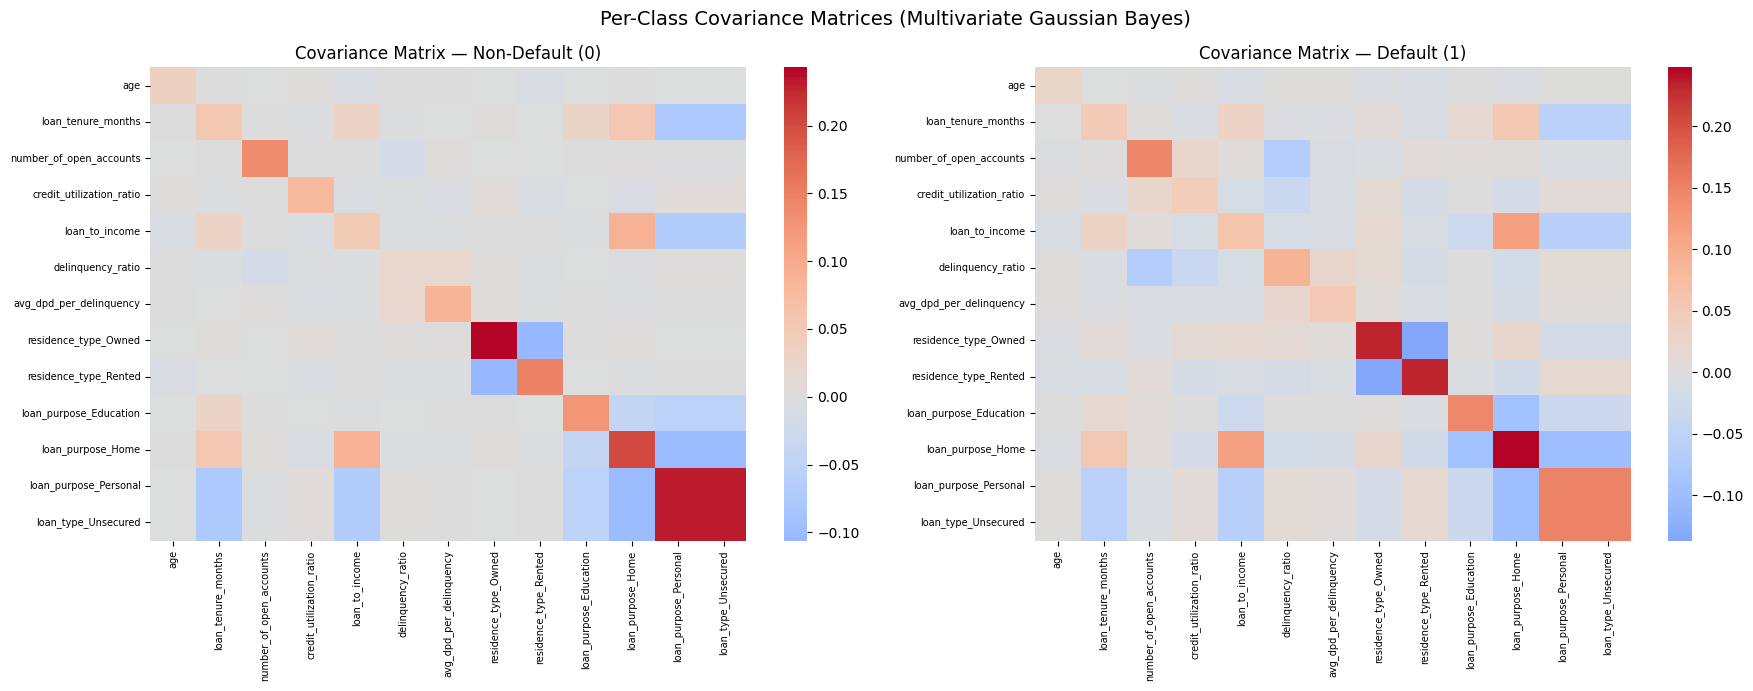

In [102]:
# Visualise the per-class covariance matrices as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, c, label in zip(axes, model_mvg.classes_, ['Non-Default (0)', 'Default (1)']):
    cov = model_mvg.params_[c]['cov']
    sns.heatmap(cov, ax=ax, cmap='coolwarm', center=0,
                xticklabels=X_train_encoded.columns,
                yticklabels=X_train_encoded.columns)
    ax.set_title(f"Covariance Matrix — {label}", fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.suptitle("Per-Class Covariance Matrices (Multivariate Gaussian Bayes)", fontsize=14)
plt.tight_layout()
plt.show()


**Insights**  
- The covariance heatmap shows **which features co-vary** within each class — information completely ignored by Naive Bayes.  
- Where GNB and MVG-Bayes differ most in predictions, the features involved are likely **highly correlated**.  
- The Mahalanobis distance `(x-μ)ᵀ Σ⁻¹ (x-μ)` replaces the sum of squared z-scores used in GNB — it accounts for feature scale **and** correlation simultaneously.

---
## 📚 Extension 3 — Formula & Syllabus Explanation

### Syllabus: Module 2 — Linear Transformation of Gaussian Random Variables, Covariance Matrix, Eigen-decomposition

### Purpose
Instead of upgrading the model (like Extension 2), this extension **transforms the data** so the original simple GNB model becomes valid. PCA finds a new coordinate system where features are completely uncorrelated — after which GNB's independence assumption holds exactly.

> **Note:** The same `GaussianNaiveBayes` class from the base model is reused here. All new work is in the transformation applied before it.

---

### Step 1 — Covariance Matrix
```python
cov_matrix = np.cov(X_np.T)   # shape: (d, d)
```
Same covariance matrix as Extension 2. Captures how features co-vary with each other.

**Syllabus link:** Module 2 — *Joint Central Moments, Covariance Matrix*

---

### Step 2 — Eigen-decomposition
The covariance matrix is factored as:

```
Σ = V Λ Vᵀ
```

- **V** = matrix of eigenvectors (the principal component directions)
- **Λ** = diagonal matrix of eigenvalues (variance along each direction)

```python
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
explained_var_ratio = eigenvalues / eigenvalues.sum()
```

**Syllabus link:** Module 2 — *"Linear Transformation of Gaussian Random Variables"* — the eigenvectors of Σ are exactly the axes of maximum variance studied here.

---

### Step 3 — Linear Projection (the key Module 2 formula)

```
Y = X @ W       where W = top k eigenvectors
```

After this projection, the covariance of Y becomes:

```
Cov(Y) = Wᵀ Σ W = Λ   (diagonal — no off-diagonal correlations)
```

Because **Λ is diagonal**, features in Y are completely **uncorrelated** — so the Naive independence assumption GNB makes is now mathematically justified.

```python
W = eigenvectors[:, :k]
X_train_pca = X_np @ W    # projected train set
X_test_pca  = X_test_np @ W   # same W applied to test (no refitting)
```

---

### Step 4 — Run original GNB on transformed features
```python
model_gnb_pca = GaussianNaiveBayes()
model_gnb_pca.fit(X_train_pca_df, y_train_smt)
```

The same `GaussianNaiveBayes` class is applied — now on decorrelated principal component features instead of the original correlated ones.


<h3 align='center' style='color:blue'>Extension 3 – PCA + Gaussian Naive Bayes</h3>

### Syllabus link: Linear Transformation of Gaussian Random Variables
If **X** is a Gaussian random vector and **W** is a linear transformation matrix, then:

`Y = Wᵀ X`

**Y is also Gaussian** — its covariance becomes `Wᵀ Σ W`.

**PCA finds W** = eigenvectors of the covariance matrix, ordered by eigenvalue (variance explained).  
After projection, features in Y are **uncorrelated** → the Naive independence assumption becomes more valid.

Steps:  
1. Compute covariance matrix Σ  
2. Eigen-decompose: `Σ = V Λ Vᵀ`  
3. Project: `Y = X @ V[:, :k]`  
4. Train Naive Bayes on Y

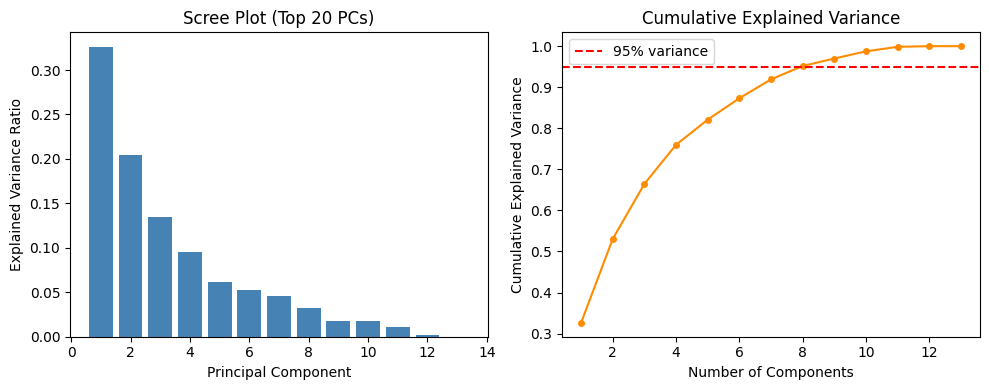

Components needed to explain 95% variance: 8


In [103]:
# ── PCA from scratch ──────────────────────────────────────────────────────
X_np = X_train_smt.values.astype(float)
X_test_np = X_test_encoded.values.astype(float)

# Step 1: Covariance matrix
cov_matrix = np.cov(X_np.T)   # shape: (d, d)

# Step 2: Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Explained variance ratio
explained_var_ratio = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var_ratio)

# Plot scree
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
n_show = min(20, len(explained_var_ratio))
plt.bar(range(1, n_show + 1), explained_var_ratio[:n_show], color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (Top 20 PCs)')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', markersize=4, color='darkorange')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()

plt.tight_layout()
plt.show()

# Find k for 95% variance
k_95 = int(np.argmax(cumulative_var >= 0.95)) + 1
print(f"Components needed to explain 95% variance: {k_95}")


In [104]:
# Step 3: Project data onto top k PCs
k = k_95
W = eigenvectors[:, :k]          # projection matrix  (d × k)

X_train_pca = X_np @ W           # (n_train × k)
X_test_pca  = X_test_np @ W      # (n_test  × k)

print(f"Training set shape after PCA: {X_train_pca.shape}")
print(f"Test set shape after PCA:     {X_test_pca.shape}")

# Wrap as DataFrame for reuse with our GaussianNaiveBayes class
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(k)])
X_test_pca_df  = pd.DataFrame(X_test_pca,  columns=[f'PC{i+1}' for i in range(k)])


Training set shape after PCA: (68390, 8)
Test set shape after PCA:     (12497, 8)


In [105]:
# Step 4: Train GNB on PCA-transformed features
model_gnb_pca = GaussianNaiveBayes()
model_gnb_pca.fit(X_train_pca_df, y_train_smt)

y_pred_pca = model_gnb_pca.predict(X_test_pca_df)
print("Classification Report — PCA + Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_pca))

# AUC
from sklearn.metrics import roc_curve, auc
prob_pca = model_gnb_pca.predict_proba(X_test_pca_df)[:, 1]
fpr_pca, tpr_pca, _ = roc_curve(y_test, prob_pca)
auc_pca = auc(fpr_pca, tpr_pca)
print(f"AUC (PCA + GNB): {auc_pca:.4f}")


Classification Report — PCA + Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       0.99      0.83      0.91     11423
           1       0.34      0.92      0.50      1074

    accuracy                           0.84     12497
   macro avg       0.67      0.88      0.70     12497
weighted avg       0.94      0.84      0.87     12497

AUC (PCA + GNB): 0.9513


**Insights**  
- After projecting onto the top principal components the features are **uncorrelated**, making the Naive independence assumption more justified.  
- Compare AUC here vs the original GNB — any drop indicates information lost in compression; any gain means the original features had redundant noise.  
- The covariance eigen-decomposition directly connects to **Module 2 (Joint Gaussian, Covariance Matrix)** of the syllabus.

---
## 📚 Extension 4 — Formula & Syllabus Explanation

### Syllabus: Module 6 — Noise Definitions, White Noise, Gaussian Noise, System Evaluation using Random Noise

### The Noise Model
This extension applies the standard **signal-plus-noise** model from Module 6 directly to your credit risk features:

```
x_noisy = x + n,    where  n ~ N(0, σ²)
```

- **x** = the clean feature value (the "signal")
- **n** = additive white Gaussian noise with standard deviation σ
- **σ** = the noise level, swept from 0 (perfectly clean) to 1.0 (heavily corrupted)

This is exactly the model studied in Module 6: `y = s + n`.

---

### What the code does

```python
noise = np.random.default_rng(42).normal(0, sigma, X_test_clean.shape)
X_noisy = X_test_clean + noise
```

- `normal(0, sigma, shape)` draws samples from **N(0, σ²)** — Gaussian noise with zero mean and variance σ²
- Adding it to `X_test_clean` simulates real-world measurement corruption
- AUC is measured at each σ level for both GNB and Multivariate Gaussian Bayes

---

### How to read the AUC vs σ plot

| What you observe | What it means |
|---|---|
| AUC stays high as σ grows | Model is robust — feature signal dominates noise |
| AUC drops sharply at low σ | Model is noise-sensitive — features are close between classes |
| GNB drops faster than MVG | Covariance structure in MVG Bayes helps absorb noise better |
| Both drop together | Noise overwhelms all features equally |

**Syllabus link:** Module 6 — *"System Evaluation using Random Noise"* and *"Noise Bandwidth"*. Sweeping σ from 0→1 is equivalent to evaluating the classifier's noise bandwidth.


<h3 align='center' style='color:blue'>Extension 4 – Effect of Gaussian Noise on Classification</h3>

### Syllabus link: Gaussian Noise Modeling (Module 6)
We simulate how **additive Gaussian noise** degrades model performance.

The corrupted observation is:  
`x_noisy = x + n,    n ~ N(0, σ²)`

We sweep σ from 0 (clean) to 1.0 (heavy noise) and measure AUC for both  
**GNB** and **Multivariate Gaussian Bayes** — showing which is more robust.

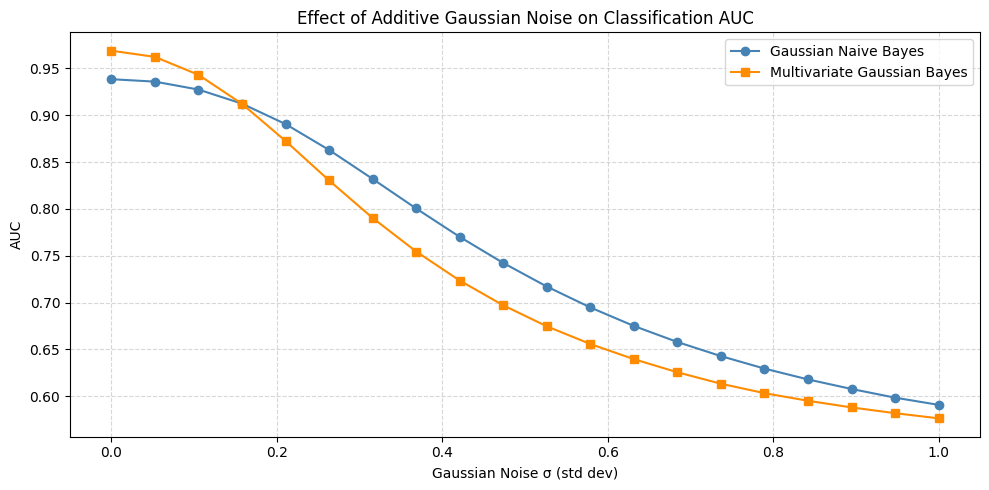

In [106]:
noise_levels = np.linspace(0, 1.0, 20)
X_test_clean = X_test_encoded.values.astype(float)

auc_gnb_noise  = []
auc_mvg_noise  = []

for sigma in noise_levels:
    noise = np.random.default_rng(42).normal(0, sigma, X_test_clean.shape)
    X_noisy = X_test_clean + noise

    # GNB
    prob_n = model_gnb.predict_proba(pd.DataFrame(X_noisy, columns=X_test_encoded.columns))[:, 1]
    fpr_n, tpr_n, _ = roc_curve(y_test, prob_n)
    auc_gnb_noise.append(auc(fpr_n, tpr_n))

    # Multivariate Gaussian Bayes
    prob_m = model_mvg.predict_proba(X_noisy)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, prob_m)
    auc_mvg_noise.append(auc(fpr_m, tpr_m))

plt.figure(figsize=(10, 5))
plt.plot(noise_levels, auc_gnb_noise, marker='o', label='Gaussian Naive Bayes', color='steelblue')
plt.plot(noise_levels, auc_mvg_noise, marker='s', label='Multivariate Gaussian Bayes', color='darkorange')
plt.xlabel('Gaussian Noise σ (std dev)')
plt.ylabel('AUC')
plt.title('Effect of Additive Gaussian Noise on Classification AUC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


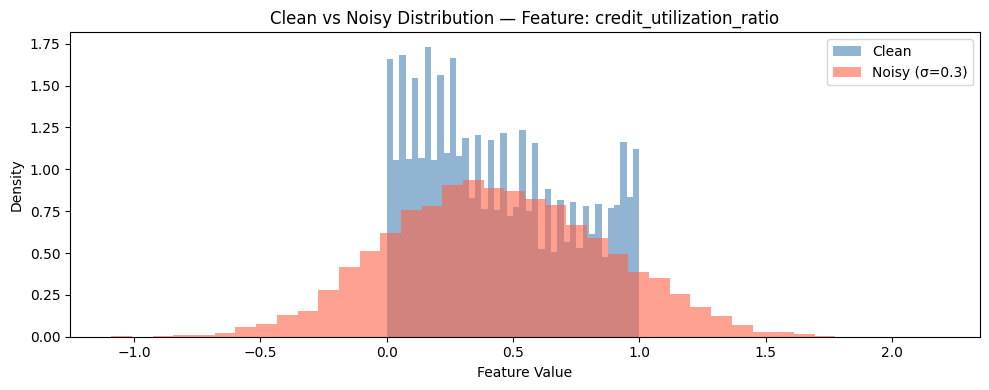

In [107]:
# Show sample noisy vs clean distributions for the most important feature
top_feature = importance_df.sort_values('Mean Difference', ascending=False).iloc[0]['Feature']
feat_idx = list(X_test_encoded.columns).index(top_feature)

sigma_demo = 0.3
noise_demo = np.random.default_rng(0).normal(0, sigma_demo, len(X_test_clean))

plt.figure(figsize=(10, 4))
plt.hist(X_test_clean[:, feat_idx], bins=40, density=True, alpha=0.6, label='Clean', color='steelblue')
plt.hist(X_test_clean[:, feat_idx] + noise_demo, bins=40, density=True, alpha=0.6, label=f'Noisy (σ={sigma_demo})', color='tomato')
plt.title(f"Clean vs Noisy Distribution — Feature: {top_feature}")
plt.xlabel('Feature Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


**Insights**  
- As σ increases, AUC drops — noise corrupts the likelihood estimates both models rely on.  
- **Multivariate Gaussian Bayes** uses the inverse covariance (Mahalanobis distance), which can be more or less robust depending on whether noise shifts features along correlated directions.  
- This experiment directly mirrors **signal detection in Gaussian noise** from Module 6: `y = s + n, n ~ N(0, σ²)`.

---
## 📊 Final Model Comparison — What to Expect

This section overlays the ROC curves of all three models on a single plot and prints a summary table of AUC and Gini coefficient.

| Model | Key property | Expected behaviour |
|---|---|---|
| Gaussian Naive Bayes | Independent features, per-feature σ² | Baseline — strong if features are Gaussian and uncorrelated |
| PCA + GNB | Decorrelated features via eigen-decomposition | Similar or slightly lower AUC — may lose information in compression |
| Multivariate Gaussian Bayes | Full covariance Σ, Mahalanobis distance | Should match or exceed GNB when features are correlated |

**Gini coefficient** = 2 × AUC − 1. It ranges from 0 (random) to 1 (perfect). A Gini > 0.7 is considered strong for credit risk models.


<h3 align='center' style='color:blue'>Final Model Comparison</h3>

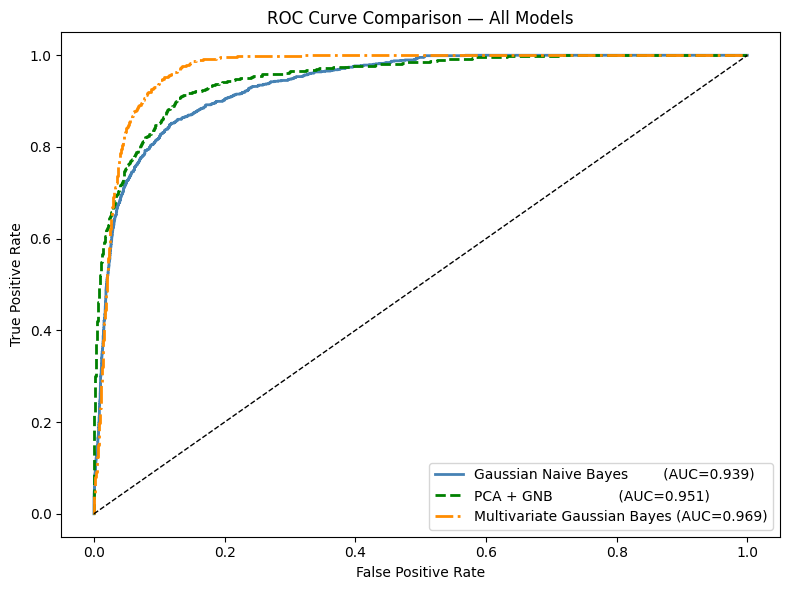

,Model,AUC,Gini
0,Gaussian Naive Bayes,0.939,0.877
1,PCA + GNB,0.951,0.903
2,Multivariate Gaussian Bayes,0.969,0.938


In [108]:
# Compare all three models on ROC curve
plt.figure(figsize=(8, 6))

# Original GNB
plt.plot(fpr, tpr, label=f'Gaussian Naive Bayes        (AUC={area:.3f})', color='steelblue', lw=2)

# PCA + GNB
plt.plot(fpr_pca, tpr_pca, label=f'PCA + GNB               (AUC={auc_pca:.3f})', color='green', lw=2, linestyle='--')

# Multivariate Gaussian Bayes
plt.plot(fpr_mvg, tpr_mvg, label=f'Multivariate Gaussian Bayes (AUC={auc_mvg:.3f})', color='darkorange', lw=2, linestyle='-.')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Model': ['Gaussian Naive Bayes', 'PCA + GNB', 'Multivariate Gaussian Bayes'],
    'AUC':   [round(area, 4), round(auc_pca, 4), round(auc_mvg, 4)],
    'Gini':  [round(2*area-1, 4), round(2*auc_pca-1, 4), round(2*auc_mvg-1, 4)]
})
display(summary)


---
## 📚 Full Syllabus Coverage Map

| Syllabus Topic | Module | Used In |
|---|---|---|
| Random Variables, Distributions | Module 1 | Base GNB — prior probability, Gaussian PDF |
| Gaussian Distribution & Density Function | Module 1 | Base GNB — `_pdf` method (Gaussian likelihood) |
| Density of Functions of Random Variables | Module 1 | Base GNB — log transformation of PDF product |
| Statistical Independence | Module 1 | Extension 1 — KL Divergence measures deviation from Gaussian |
| Joint Central Moments | Module 2 | Extension 2 — `np.cov()` computes covariance matrix |
| Jointly Gaussian Random Variables | Module 2 | Extension 2 — full multivariate Gaussian PDF |
| Covariance Matrix | Module 2 | Extension 2 & 3 — Σ used in both MVG Bayes and PCA |
| Transformations of Multiple Random Variables | Module 2 | Extension 2 — Mahalanobis distance via Σ⁻¹ |
| **Linear Transformation of Gaussian RVs** | **Module 2** | **Extension 3 — Y = X @ W, Cov(Y) = WᵀΣW = Λ** |
| Noise Definitions — White/Gaussian Noise | Module 6 | Extension 4 — `n ~ N(0, σ²)` additive noise model |
| System Evaluation using Random Noise | Module 6 | Extension 4 — AUC vs σ curve |
| Noise Bandwidth | Module 6 | Extension 4 — sweeping σ from 0 to 1.0 |

> **Modules not covered:** Modules 3, 4, 5 (Random Processes — temporal/spectral, linear systems) require a time-series or signal processing task, not a tabular classifier.
